# Optiver 2-Level LOB + Transfer Learning Report

This notebook now documents the split Optiver workflow with two independent prediction tasks over the same retained transfer-learning slice:

1. Classification: 3-class direction prediction under `results/optiver/`
2. Regression: future log-return prediction under `results/optiver/regression/`

Both tasks reuse the same retained Optiver design choices:

- horizon `k = 5` only
- held-out transfer stocks `5, 17, 42, 108, 120` only
- `volatility` base sampling
- the same 2-level DeepLOBLite backbone and transfer-learning protocol

The expensive work still runs through the cluster scripts; this notebook is the final report surface that loads saved artifacts and explains the technical choices behind each branch.

## Authoritative Scope Update (2026-04-29)

This notebook's final report surface is now the **classification-only** Optiver comparison between the two retained variants:

- `Original3`: `results/optiver/classification_original3/`
- `Rolling3`: `results/optiver/classification_rolling3_w20000/`

Earlier cells that discuss the older classification/regression split are kept as archival scaffolding. The final section appended at the end of the notebook is the authoritative interpretation of the current retained results.

## 1. Cluster workflow

### Submit the classification run
```bash
cd /ocean/projects/mth250011p/xxiao7/DeepLOB
sbatch --export=ALL,OPTIVER_TASK_TYPE=classification submit_optiver.sh --force
```

### Submit the regression run
```bash
cd /ocean/projects/mth250011p/xxiao7/DeepLOB
sbatch --export=ALL,OPTIVER_TASK_TYPE=regression submit_optiver.sh --force
```

The cleaned Optiver project keeps one retained transfer slice, but now evaluates it with two different task heads:
1. `scripts/prepare_optiver.py` prepares the interleaved stock split and causal normalization once.
2. `scripts/train_optiver.py` runs the retained `k = 5` transfer workflow in either classification or regression mode.
3. `scripts/analyze_optiver.py` writes the final transfer-analysis figures into the task-specific result directory for that same retained slice.

This notebook therefore reads two active Optiver result trees:
- `results/optiver/` for classification
- `results/optiver/regression/` for regression

## 2. Setup

In [ ]:
import io, json, os, pickle, subprocess, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

BASE_DIR = Path('/ocean/projects/mth250011p/xxiao7/DeepLOB')
ZIP_PATH = BASE_DIR / 'optiver-realized-volatility-prediction.zip'
DATA_DIR = BASE_DIR / 'data' / 'optiver_processed'
OPTIVER_CLASS_RESULT_DIR = BASE_DIR / 'results' / 'optiver'
OPTIVER_REG_RESULT_DIR = BASE_DIR / 'results' / 'optiver' / 'regression'
RESULT_DIR = OPTIVER_CLASS_RESULT_DIR
HORIZONS = [5]
OPTIVER_JOB_IDS = {'classification': 40329857, 'regression': 40329858}

print('Classification RESULT_DIR =', OPTIVER_CLASS_RESULT_DIR)
print('Regression RESULT_DIR =', OPTIVER_REG_RESULT_DIR)
print('Report horizons:', HORIZONS)
print('Tracked job IDs:', OPTIVER_JOB_IDS)


In [ ]:
# Live Optiver job snapshot and artifact availability for both tasks
def _run_shell(cmd):
    completed = subprocess.run(['bash', '-lc', cmd], capture_output=True, text=True)
    if completed.returncode == 0:
        return completed.stdout.strip()
    return completed.stderr.strip()

job_snapshot = _run_shell("squeue -u xxiao7 | awk 'NR==1 || /optiver_/'")
print(job_snapshot or 'No matching Optiver jobs are currently visible in squeue.')

artifact_specs = {
    'classification': {
        'result_dir': OPTIVER_CLASS_RESULT_DIR,
        'required': [
            'base_metrics_k5.pkl', 'transfer_metrics_k5.pkl', 'specific_metrics_k5.pkl',
            'transfer_analysis_summary.json', 'figure6_transfer_accuracy.png'
        ],
    },
    'regression': {
        'result_dir': OPTIVER_REG_RESULT_DIR,
        'required': [
            'base_metrics_k5.pkl', 'transfer_metrics_k5.pkl', 'specific_metrics_k5.pkl',
            'transfer_analysis_summary.json', 'figure6_transfer_accuracy.png'
        ],
    },
}

rows = []
for task, spec in artifact_specs.items():
    for name in spec['required']:
        path = spec['result_dir'] / name
        rows.append({
            'task': task,
            'artifact': name,
            'exists': path.exists(),
            'path': str(path),
        })

status_df = pd.DataFrame(rows)
display(status_df)

for task, spec in artifact_specs.items():
    summary_path = spec['result_dir'] / 'transfer_analysis_summary.json'
    if summary_path.exists():
        print(f'\n{task.title()} transfer analysis summary:')
        with open(summary_path, 'r') as f:
            summary = json.load(f)
        display(pd.DataFrame(summary.get('per_stock_horizon', [])))
    else:
        print(f'\n{task.title()} transfer analysis summary is not available yet.')


## 2A. Task Split, Components, Metrics, and Parameter Choices

### Current status snapshot (2026-04-27)

- `optiver_cls` (`40329857`) is pending.
- `optiver_reg` (`40329858`) is pending.
- Both jobs are waiting behind the Bridges-2 per-user job limit, so this notebook now documents the task split and is ready to load either branch as soon as the artifacts appear on disk.

### Shared retained Optiver components

Both Optiver tasks reuse the same retained transfer-learning slice and the same backbone design in `scripts/train_optiver.py`:

- Data domain: 2-level LOB only, so each event window has `8` features instead of the original `40`.
- Backbone: three convolution blocks, DeepLOB inception module, single-layer LSTM, dropout, then a task-specific head.
- Structural change relative to FI DeepLOB: the last width-collapsing convolution uses kernel `(1, 2)` instead of `(1, 10)` because the Optiver book width is reduced to two levels.
- Retained horizon: `k = 5` only.
- Retained held-out transfer stocks: `5, 17, 42, 108, 120`.
- Retained base-sampling mode: `volatility`.
- Base validation mode: temporal split with `base_val_frac = 0.15`.
- Base epochs: `50`, transfer epochs: `24`, specific-stock epochs: `36`, lookback: `50`.

### Task-specific heads and targets

| Task | Target | Output head | Loss / monitor | Main evaluation metrics | Key diagnostics | Result tree |
|---|---|---|---|---|---|---|
| Classification | 3-class direction labels rebuilt with `stock-quantile` mode | `fc1 -> R^3` logits head | Focal loss, monitor `val_macro_f1` | Accuracy, macro-F1, Cohen kappa, MCC | confusion matrices, transfer accuracy comparisons, profit-style session analysis, LIME-style class explanation | `results/optiver/` |
| Regression | future log return `log(mid_{t+5}) - log(mid_t)` | scalar `reg_head` | Huber regression loss, monitor `val_reg_corr` | correlation, RMSE, MAE, sign accuracy | predicted-vs-actual scatter, regression transfer comparison, sign-based pseudo-profit summaries, LIME-style continuous surrogate | `results/optiver/regression/` |

### Why these metrics were chosen

- Classification keeps `val_macro_f1` as the preferred monitor because the Optiver held-out stocks are class-imbalance sensitive and macro-F1 is more resistant than accuracy to a dominant stationary-class solution.
- Regression uses `val_reg_corr` for model selection because the main goal is directional co-movement with future returns, while RMSE and MAE still quantify scale error and sign accuracy measures tradable direction consistency.
- The post-training analysis script keeps the same figure family and filenames within each result tree, but interprets them differently for regression: confusion-style panels become scatter or sign-profit diagnostics, and the LIME-style explanation uses a continuous response instead of class probability.

### Retained `k = 5` classification parameters

| Component | Choice | Reason |
|---|---|---|
| Learning rate | `1.2e-4` | stable base training on the retained cross-stock slice |
| Transfer LR | `2e-5` | smaller step size for stock-specific adaptation |
| Dropout | `0.30` | regularizes the shared representation on cross-stock transfer |
| Patience / min epochs | `10 / 10` | allows mild oscillation without overextending unstable runs |
| Label mode | `stock-quantile` | reduces trivial majority-class predictions stock by stock |
| Stationary fraction | `0.30` | retained from the cleaned `k=5` configuration |
| Balance mode | `loss` | class imbalance handled through the loss rather than sampler duplication |
| Loss type | `focal` | helps suppress majority-class collapse on held-out stocks |
| Transfer mode | `auto` | compares candidate fine-tuning scopes per stock and records the selected one |

### Retained `k = 5` regression parameters

| Component | Choice | Reason |
|---|---|---|
| Learning rate | `1.2e-4` | preserve the same stable backbone schedule as the classification branch |
| Transfer LR | `2e-5` | same cautious transfer step size |
| Dropout | `0.30` | same retained regularization strength |
| Patience / min epochs | `10 / 10` | same training budget on the retained slice |
| Target construction | `log(mid_{t+5}) - log(mid_t)` | direct continuous return objective |
| Regression loss | Huber (`beta=1.0`, clip=`5.0`) | robust to heavy-tailed return outliers after standardization |
| Balance mode | `none` | class balancing is meaningless for a continuous target |
| Monitor | `val_reg_corr` | best aligned with return co-movement quality |
| Transfer mode | `auto` | still compares fine-tuning scopes, but selects by regression monitor rather than macro-F1 |

### Important implementation consequences

- Classification and regression now write to different result trees, so their figures, metrics, and transfer summaries no longer overwrite each other.
- The regression branch does not reuse the classification labels at all; it rebuilds continuous log-return targets on load from the stored mid-price array in the processed stock files.
- The analysis script is task-aware, so the same notebook can compare classification and regression without switching code branches manually.

## 3. Raw Optiver dataset overview

In [2]:
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    names = zf.namelist()
    tops = sorted(set(n.split('/')[0] for n in names if '/' in n))
    print('Top-level directories:', tops)
    print('Top-level files:', [n for n in names if '/' not in n])
    with zf.open('train.csv') as f:
        df_train = pd.read_csv(f)

print('train.csv shape:', df_train.shape)
display(df_train.head())

Top-level directories: ['book_test.parquet', 'book_train.parquet', 'trade_test.parquet', 'trade_train.parquet']
Top-level files: ['sample_submission.csv', 'test.csv', 'train.csv']
train.csv shape: (428932, 3)


,stock_id,time_id,target
0,0,5,0.004136
1,0,11,0.001445
2,0,16,0.002168
3,0,31,0.002195
4,0,62,0.001747


In [3]:
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    book_name = next(n for n in zf.namelist() if n.startswith('book_train.parquet/stock_id=0/'))
    trade_name = next(n for n in zf.namelist() if n.startswith('trade_train.parquet/stock_id=0/'))
    df_book = pd.read_parquet(io.BytesIO(zf.read(book_name)))
    df_trade = pd.read_parquet(io.BytesIO(zf.read(trade_name)))

print('Sample book rows')
display(df_book.head())
print('Sample trade rows')
display(df_trade.head())

Sample book rows


,time_id,seconds_in_bucket,bid_price1,ask_price1,bid_price2,ask_price2,bid_size1,ask_size1,bid_size2,ask_size2
0,5,0,1.001422,1.002301,1.00137,1.002353,3,226,2,100
1,5,1,1.001422,1.002301,1.00137,1.002353,3,100,2,100
2,5,5,1.001422,1.002301,1.00137,1.002405,3,100,2,100
3,5,6,1.001422,1.002301,1.00137,1.002405,3,126,2,100
4,5,7,1.001422,1.002301,1.00137,1.002405,3,126,2,100


Sample trade rows


,time_id,seconds_in_bucket,price,size,order_count
0,5,21,1.002301,326,12
1,5,46,1.002778,128,4
2,5,50,1.002818,55,1
3,5,57,1.003155,121,5
4,5,68,1.003646,4,1


## 4. Feature arrangement, normalization, and labels

The Optiver dataset only provides the first **two** bid/ask levels, so the input tensor is reduced from 40 features (FI-2010, 10 levels) to 8 features:

```
[ask_price1, ask_size1, bid_price1, bid_size1,
 ask_price2, ask_size2, bid_price2, bid_size2]
```

This ordering is intentional: the first `(1×2, stride=2)` convolution still merges **price + size within the same side and level**, preserving the design logic of the original DeepLOB paper.

The refreshed preprocessing no longer defaults to bucket-level `time_id` normalization. It now uses a **causal event-wise rolling z-score with clipping** so each stock is normalized from its own past observations while avoiding the extreme scale blow-ups seen in the older preprocessing.

Raw labels are constructed from event-horizon mid-price returns with an adaptive threshold:

```
return_t(k) = (mid_{t+k} - mid_t) / mid_t
threshold_t = alpha × rolling_std(return_t(k))
```

For training, `scripts/train_optiver.py` can rebuild labels at load time with `--label-mode stock-quantile`. This makes the stationary band horizon/stock specific and reduces trivial majority-class predictions.

The curated report subset keeps the horizon `k = 5` because it is the least-collapsed slice in the latest cross-stock run.

In [5]:
split_path = DATA_DIR / 'stock_split.json'
if split_path.exists():
    split = json.loads(split_path.read_text())
    print('Train stocks   :', len(split['train']), split['train'][:5], '...', split['train'][-5:])
    print('Transfer stocks:', len(split['transfer']), split['transfer'][:5], '...', split['transfer'][-5:])
else:
    print('Processed Optiver split is not available yet. Submit submit_optiver.sh first.')

Train stocks   : 80 [0, 1, 2, 3, 4] ... [85, 86, 87, 88, 89]
Transfer stocks: 32 [90, 93, 94, 95, 96] ... [122, 123, 124, 125, 126]


## 5. DeepLOBLite architecture

The Optiver model keeps the **Conv + Inception + LSTM** backbone of DeepLOB, but adapts the spatial width to a 2-level order book. The most important structural change is the third convolution block: after two `(1×2)` reductions, the width becomes 2, so the final collapsing convolution uses `(1×2)` instead of the original `(1×10)`.

In [6]:
script = (BASE_DIR / 'scripts' / 'train_optiver.py').read_text()
start = script.index('class DeepLOBLite')
end = script.index('def train_loop(')
print(script[start:end])

class DeepLOBLite(nn.Module):
    """DeepLOB adapted for 2-level LOB (8 input features instead of 40).

    Architecture change vs. original DeepLOB (10 price levels):
      Block 3 uses kernel (1,2) instead of (1,10) to match the 2 remaining
      spatial positions after two (1,2) stride-2 convolutions.

    Input:  (B, 1, T, 8)
    Output: (B, 3) — logits
    """
    def __init__(self, y_len: int = 3):
        super().__init__()
        self.y_len = y_len

        # Block 1: merge bid/ask pairs → (B, 32, T, 4)
        self.conv1 = nn.Sequential(
            nn.Conv2d(1,  32, kernel_size=(1, 2), stride=(1, 2)),
            nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1), padding=(2, 0)),
            nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1), padding=(1, 0)),
            nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
        )
        # Block 2: merge levels → (B, 32, T, 2)
        self.conv2 = nn.Sequenti

## 6. Training and transfer-learning protocol

- **Universal feature transfer**: train one shared DeepLOBLite on the source-stock pool, then evaluate it zero-shot on held-out stocks from the interleaved `102 / 10` split.
- **Final retained scope**: both active Optiver branches keep only `k = 5` and only the held-out stocks `5, 17, 42, 108, 120`.
- **Classification branch**: uses stock-quantile direction labels, focal loss, `val_macro_f1` monitoring, and confusion-matrix / session-profit diagnostics.
- **Regression branch**: uses direct future log-return targets, Huber loss, `val_reg_corr` monitoring, and scatter / sign-accuracy diagnostics.
- **Transfer adaptation**: the active training script still evaluates multiple fine-tuning scopes through `transfer_mode=auto`, but the winning mode is selected by the task-specific monitor rather than a hard-coded classification score.
- **Specific-stock out-of-sample**: for the same held-out stocks, also train a model from scratch on the early segment of that stock and test on its later segment.
- **Training stabilizers**: causal normalization with clipping, temporal validation, capped base sampling, and the retained `volatility` base-sampling choice from the cleaned ablation stage.
- **Artifact isolation**: classification writes to `results/optiver/`, regression writes to `results/optiver/regression/`, so the two report branches can be analyzed side by side without overwriting figures or summary files.

## 7. Artifact status

In [ ]:
artifacts = []
for k in HORIZONS:
    artifacts.extend([
        f'base_loss_k{k}.png',
        f'base_metrics_k{k}.pkl',
        f'cm_base_k{k}.png',
        f'transfer_metrics_k{k}.pkl',
        f'transfer_comparison_k{k}.png',
        f'specific_metrics_k{k}.pkl',
        f'transfer_regimes_k{k}.png',
        f'transfer_loss_selected_k{k}.png',
    ])
artifacts.append('transfer_analysis_summary.json')
status = pd.DataFrame({
    'artifact': artifacts,
    'exists': [(RESULT_DIR / name).exists() for name in artifacts],
})
display(status)


,artifact,exists
0,base_loss_k1.png,True
1,base_metrics_k1.pkl,True
2,cm_base_k1.png,True
3,transfer_metrics_k1.pkl,True
4,transfer_comparison_k1.png,True
5,base_loss_k5.png,True
6,base_metrics_k5.pkl,True
7,cm_base_k5.png,True
8,transfer_metrics_k5.pkl,True
9,transfer_comparison_k5.png,True


## 8. Per-horizon training artifacts

k=1


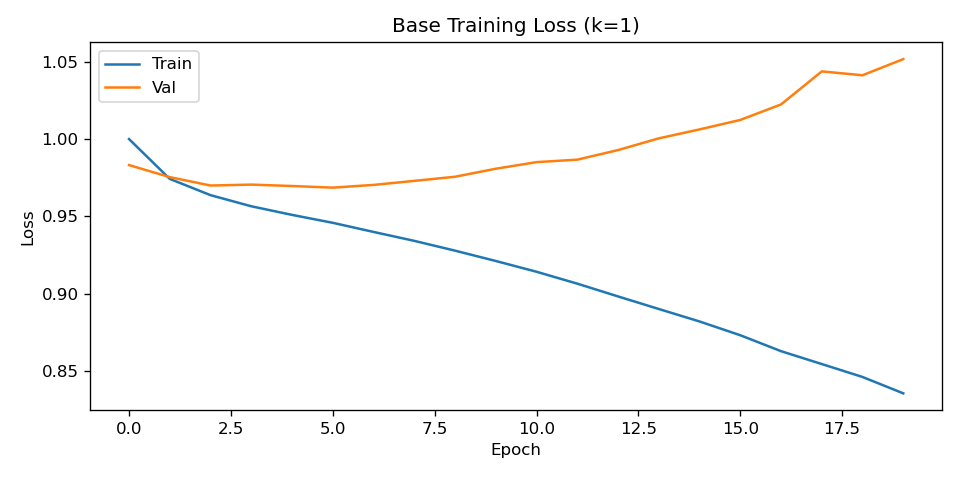

k=5


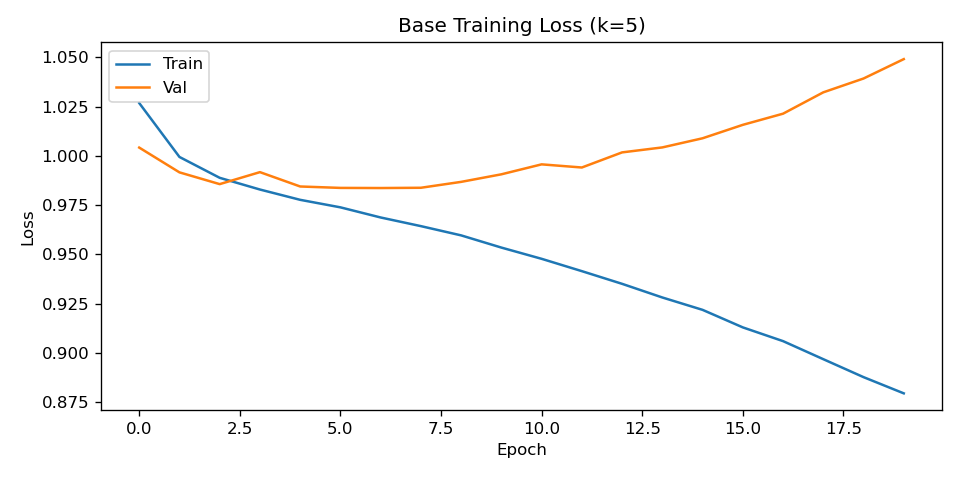

k=10


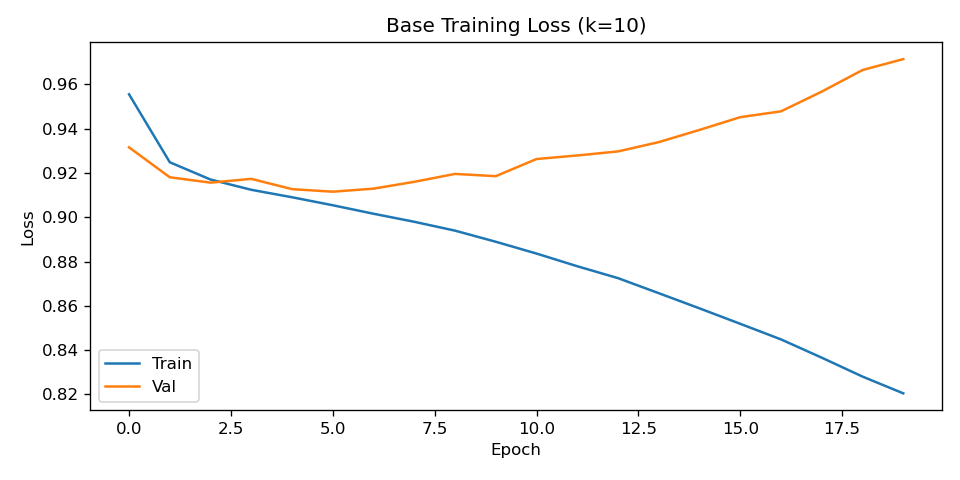

In [8]:
for k in HORIZONS:
    path = RESULT_DIR / f'base_loss_k{k}.png'
    print(f'Base training loss, k={k}')
    metrics_path = RESULT_DIR / f'base_metrics_k{k}.pkl'
    if metrics_path.exists():
        metrics = pickle.load(open(metrics_path, 'rb'))
        print('  balance_mode:', metrics.get('balance_mode', 'legacy'))
        if 'val_losses' in metrics:
            print('  best val loss:', float(np.min(metrics['val_losses'])))
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print('  base loss curve not available yet.')


In [ ]:
summary_path = RESULT_DIR / 'transfer_analysis_summary.json'
for k in HORIZONS:
    print(f'k={k}')
    transfer_metrics_path = RESULT_DIR / f'transfer_metrics_k{k}.pkl'
    if transfer_metrics_path.exists():
        transfer_metrics = pickle.load(open(transfer_metrics_path, 'rb'))
        rows = []
        for row in transfer_metrics.get('per_stock', []):
            base_collapse = row.get('base_collapse', {})
            after_collapse = row.get('after_collapse', {})
            rows.append({
                'stock_id': row['stock_id'],
                'acc_before': row['before']['accuracy'],
                'acc_after': row['after']['accuracy'],
                'delta_acc': row['after']['accuracy'] - row['before']['accuracy'],
                'base_single_class': base_collapse.get('single_class_collapse'),
                'base_dominant': base_collapse.get('dominant_label'),
                'base_share': base_collapse.get('dominant_share'),
                'selected_mode': row.get('selected_transfer_mode', row.get('transfer_mode')),
                'transfer_single_class': after_collapse.get('single_class_collapse'),
                'transfer_dominant': after_collapse.get('dominant_label'),
                'transfer_share': after_collapse.get('dominant_share'),
            })
        if rows:
            display(pd.DataFrame(rows).sort_values('stock_id').round(4).reset_index(drop=True))
    else:
        print('  transfer metrics not available yet.')

    if summary_path.exists():
        summary = json.loads(summary_path.read_text())
        rep_rows = pd.DataFrame(summary.get('representative_transfer_losses', []))
        rep_rows = rep_rows[rep_rows['horizon_k'] == k] if not rep_rows.empty else rep_rows
        if not rep_rows.empty:
            display(rep_rows[['horizon_k', 'stock_id', 'selected_transfer_mode', 'accuracy_before', 'accuracy_after', 'accuracy_delta']].round(4))

    loss_path = RESULT_DIR / f'transfer_loss_selected_k{k}.png'
    print(' ', loss_path.name)
    if loss_path.exists():
        display(Image(filename=str(loss_path)))
    else:
        print('   representative transfer loss not available yet.')

    for name in [f'transfer_comparison_k{k}.png', f'transfer_regimes_k{k}.png']:
        path = RESULT_DIR / name
        print(' ', name)
        if path.exists():
            display(Image(filename=str(path)))
        else:
            print('   not available yet.')

## 9. Summary tables across held-out transfer stocks

In [10]:
summary_path = RESULT_DIR / 'transfer_analysis_summary.json'
specific_frames = []
for k in HORIZONS:
    path = RESULT_DIR / f'specific_metrics_k{k}.pkl'
    if path.exists():
        with open(path, 'rb') as f:
            payload = pickle.load(f)
        for row in payload.get('per_stock', []):
            specific_frames.append({
                'stock_id': row['stock_id'],
                'horizon_k': k,
                'specific_accuracy': row['metrics']['accuracy'],
                'specific_kappa': row['metrics']['kappa'],
            })

if summary_path.exists():
    summary = json.loads(summary_path.read_text())
    df_summary = pd.DataFrame(summary['per_stock_horizon'])
    if specific_frames:
        df_specific = pd.DataFrame(specific_frames)
        df_summary = df_summary.merge(df_specific, on=['stock_id', 'horizon_k'], how='left')
    display(df_summary.sort_values(['horizon_k', 'stock_id']).reset_index(drop=True))
else:
    print('transfer_analysis_summary.json not available yet.')

,stock_id,horizon_k,accuracy_before,accuracy_after,accuracy_delta,profit_before_mean,profit_after_mean,profit_delta
0,90,1,0.493889,0.488889,-0.005000,0.009571,0.016351,0.006781
1,99,1,0.633889,0.626667,-0.007222,0.009956,0.003808,-0.006148
2,108,1,0.821667,0.826111,0.004444,-0.000859,0.001967,0.002826
3,116,1,0.490556,0.493333,0.002778,-0.003245,0.000261,0.003507
4,126,1,0.439444,0.438333,-0.001111,0.003771,0.003871,0.000100
5,90,5,0.472222,0.455000,-0.017222,0.064311,0.031976,-0.032335
6,99,5,0.438333,0.447778,0.009444,0.070627,0.072151,0.001523
7,108,5,0.595000,0.600000,0.005000,0.009178,-0.002882,-0.012060
8,116,5,0.471667,0.470556,-0.001111,0.112613,0.101419,-0.011195
9,126,5,0.482778,0.481667,-0.001111,0.087891,0.071344,-0.016547


In [11]:
if summary_path.exists():
    df_summary = pd.DataFrame(json.loads(summary_path.read_text())['per_stock_horizon'])
    pivot = df_summary.pivot_table(index='stock_id', columns='horizon_k', values='accuracy_delta')
    print('Accuracy gain from transfer learning (after - before):')
    display(pivot)
    if specific_frames:
        df_specific = pd.DataFrame(specific_frames)
        pivot_specific = df_specific.pivot_table(index='stock_id', columns='horizon_k', values='specific_accuracy')
        print('Specific-stock temporal OOS accuracy:')
        display(pivot_specific)

Accuracy gain from transfer learning (after - before):


horizon_k,1,5,10
stock_id,,,
90,-0.005000,-0.017222,-0.023889
99,-0.007222,0.009444,-0.003889
108,0.004444,0.005000,-0.017222
116,0.002778,-0.001111,0.008333
126,-0.001111,-0.001111,0.001111


## 10. Curated Report Figures

figure6_transfer_accuracy.png


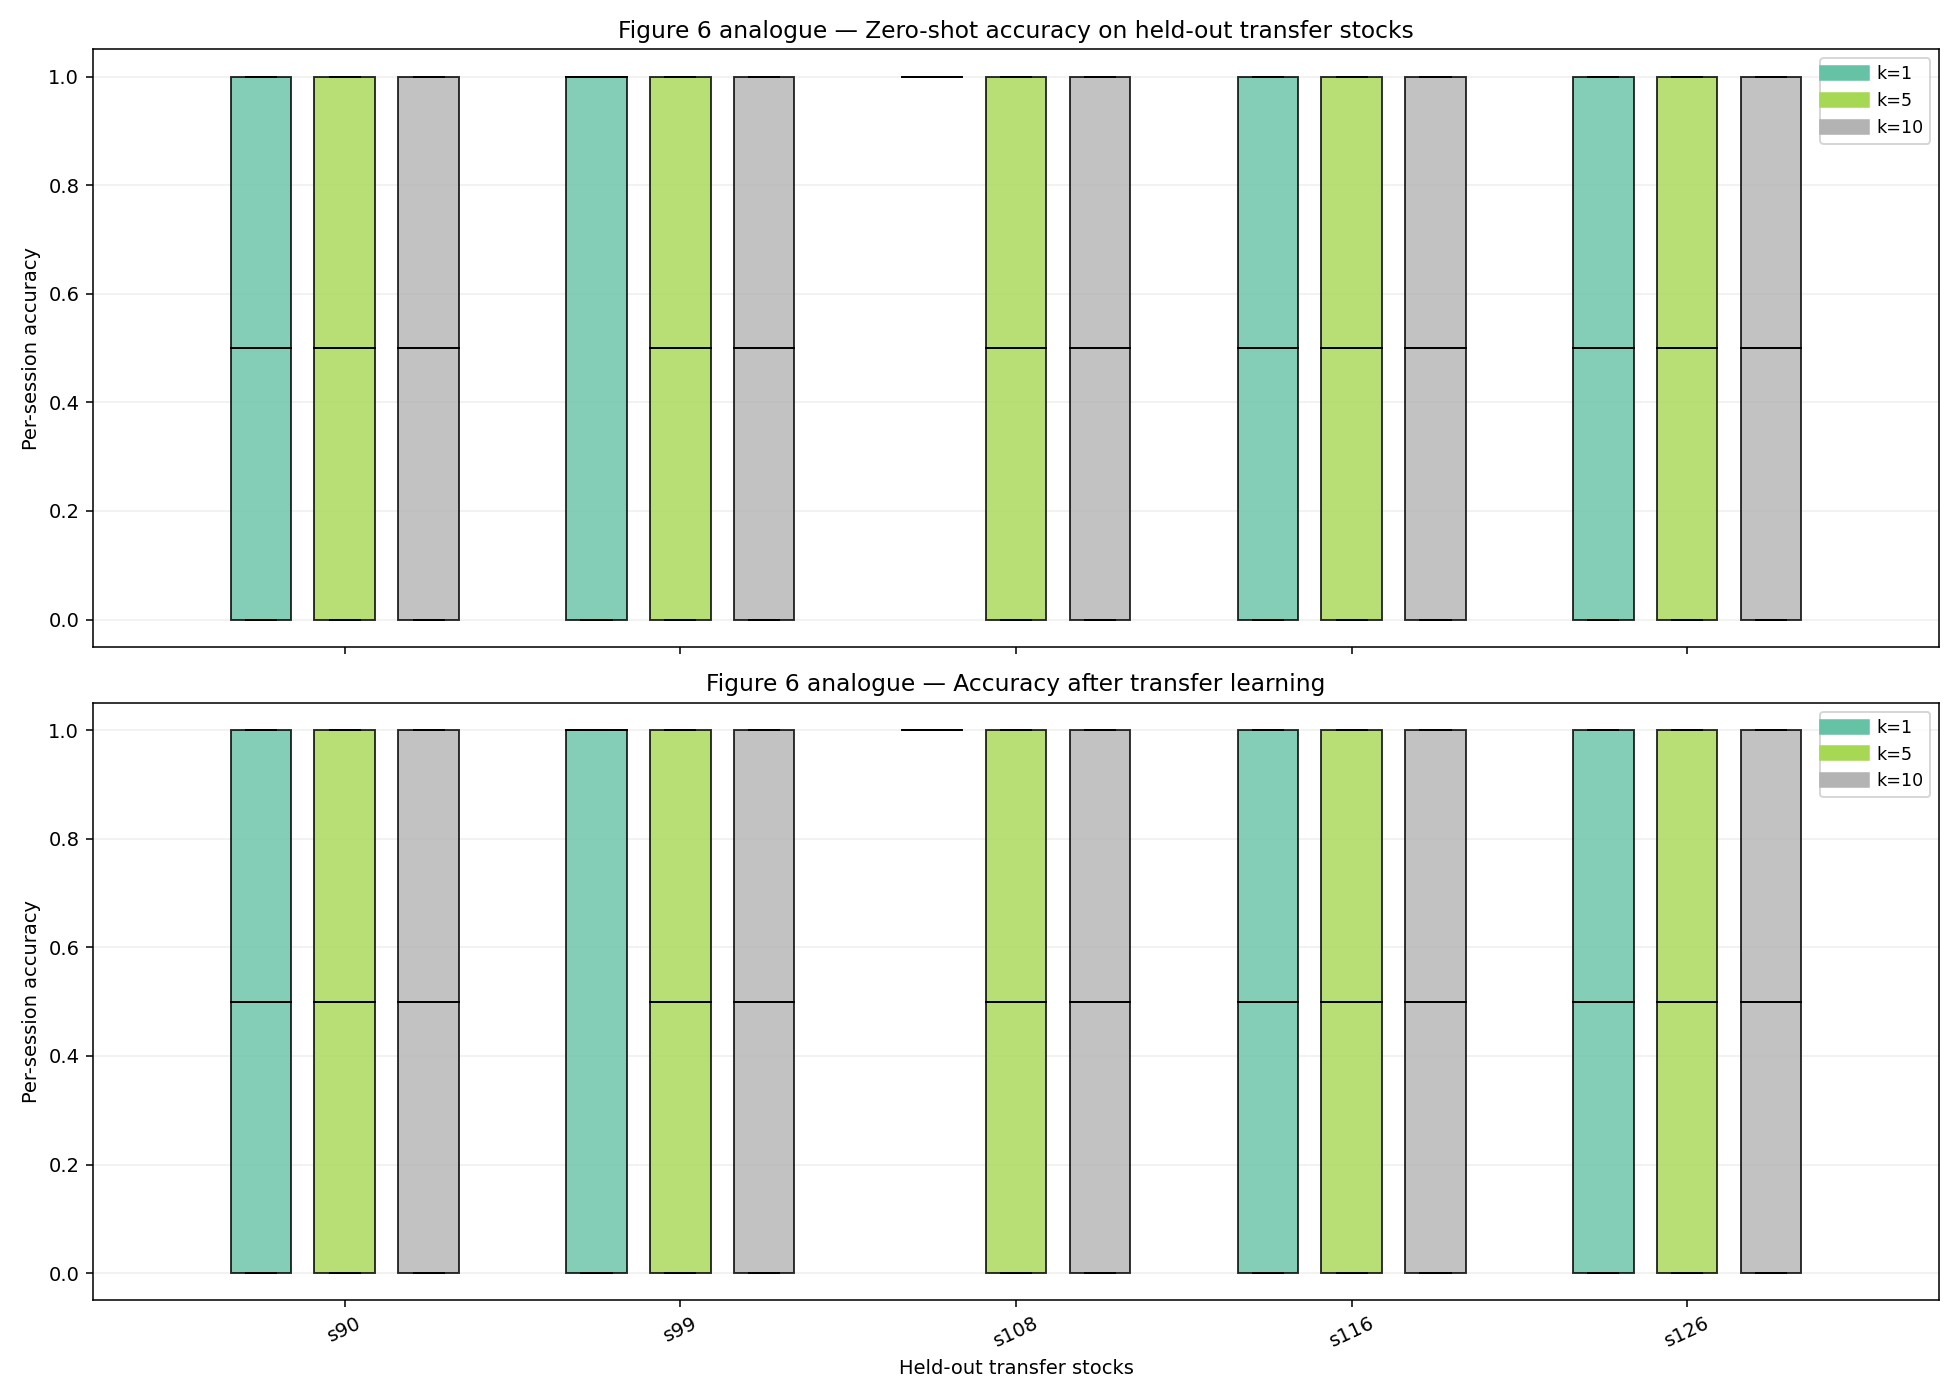

figure7_transfer_profit_tstats.png


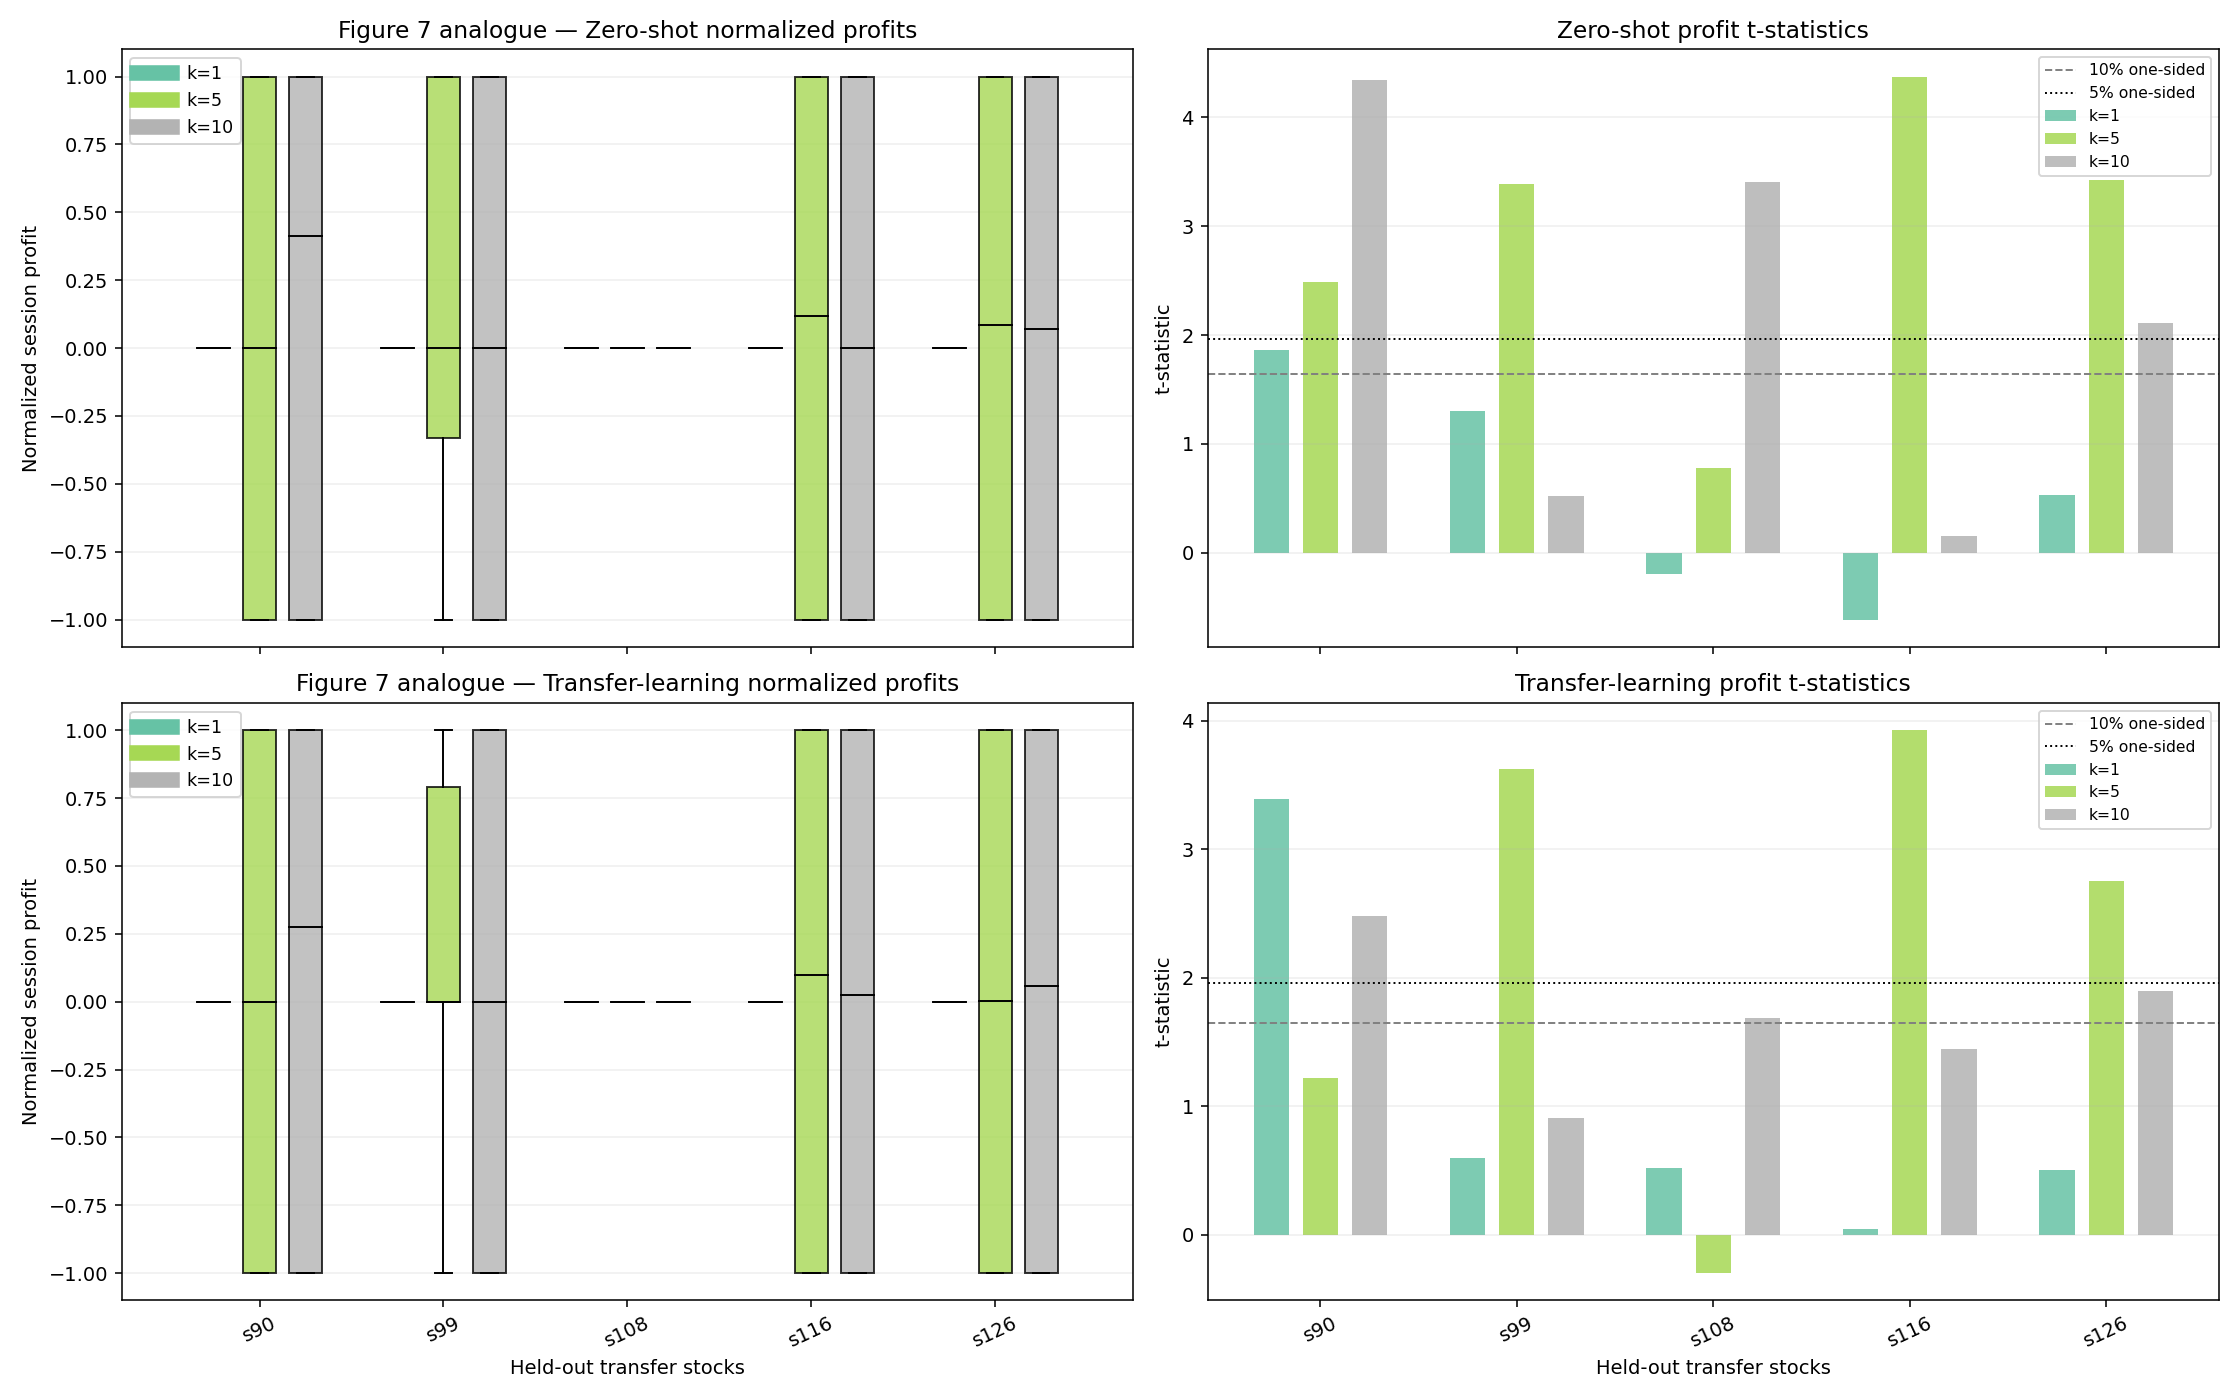

figure8_transfer_cum_profit.png


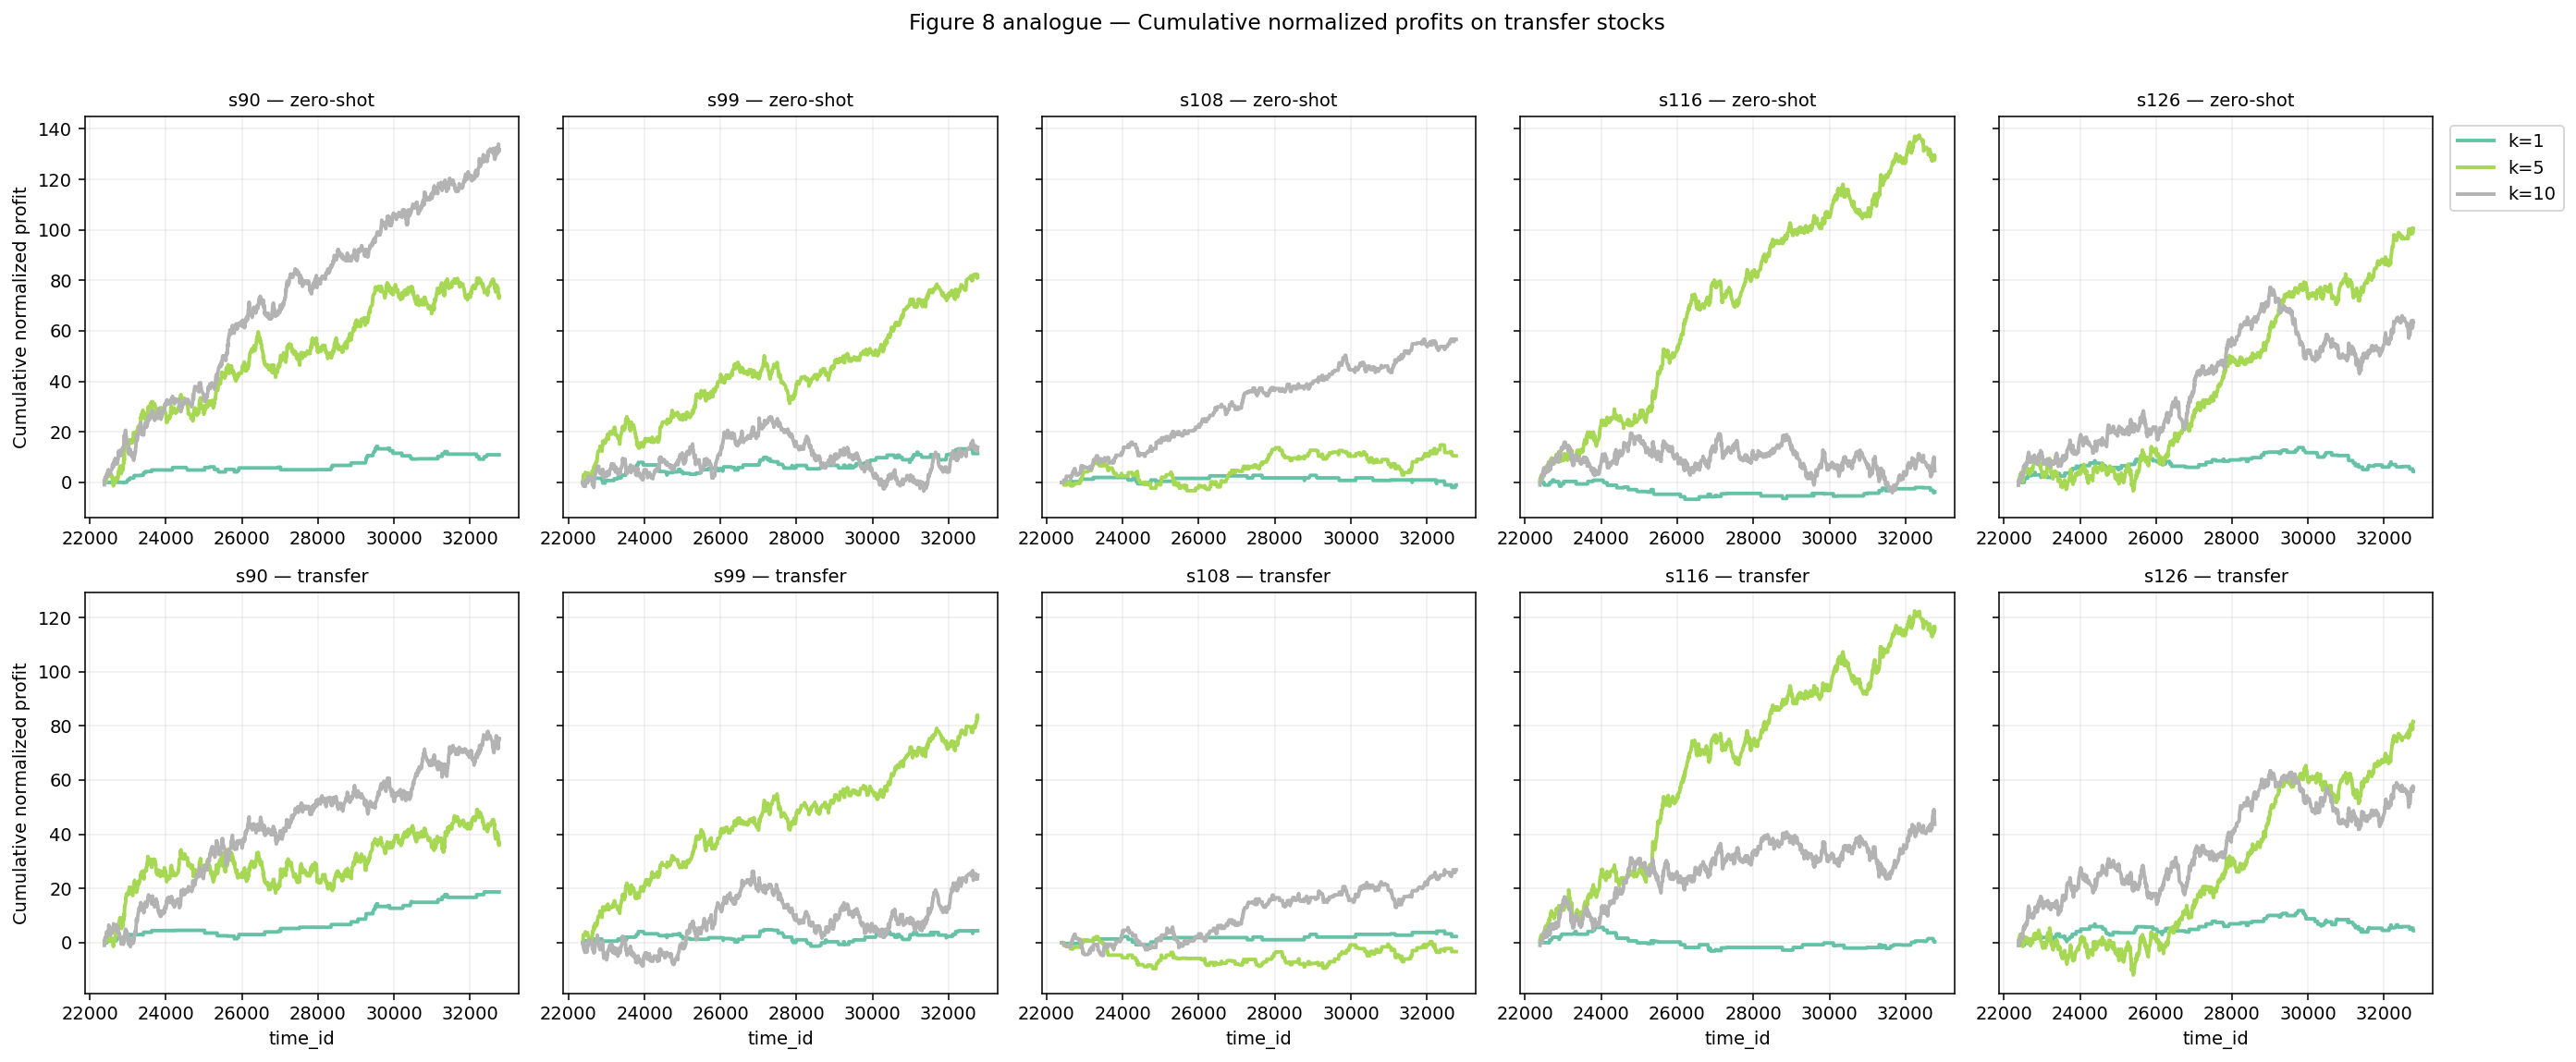

figure9_transfer_lime.png


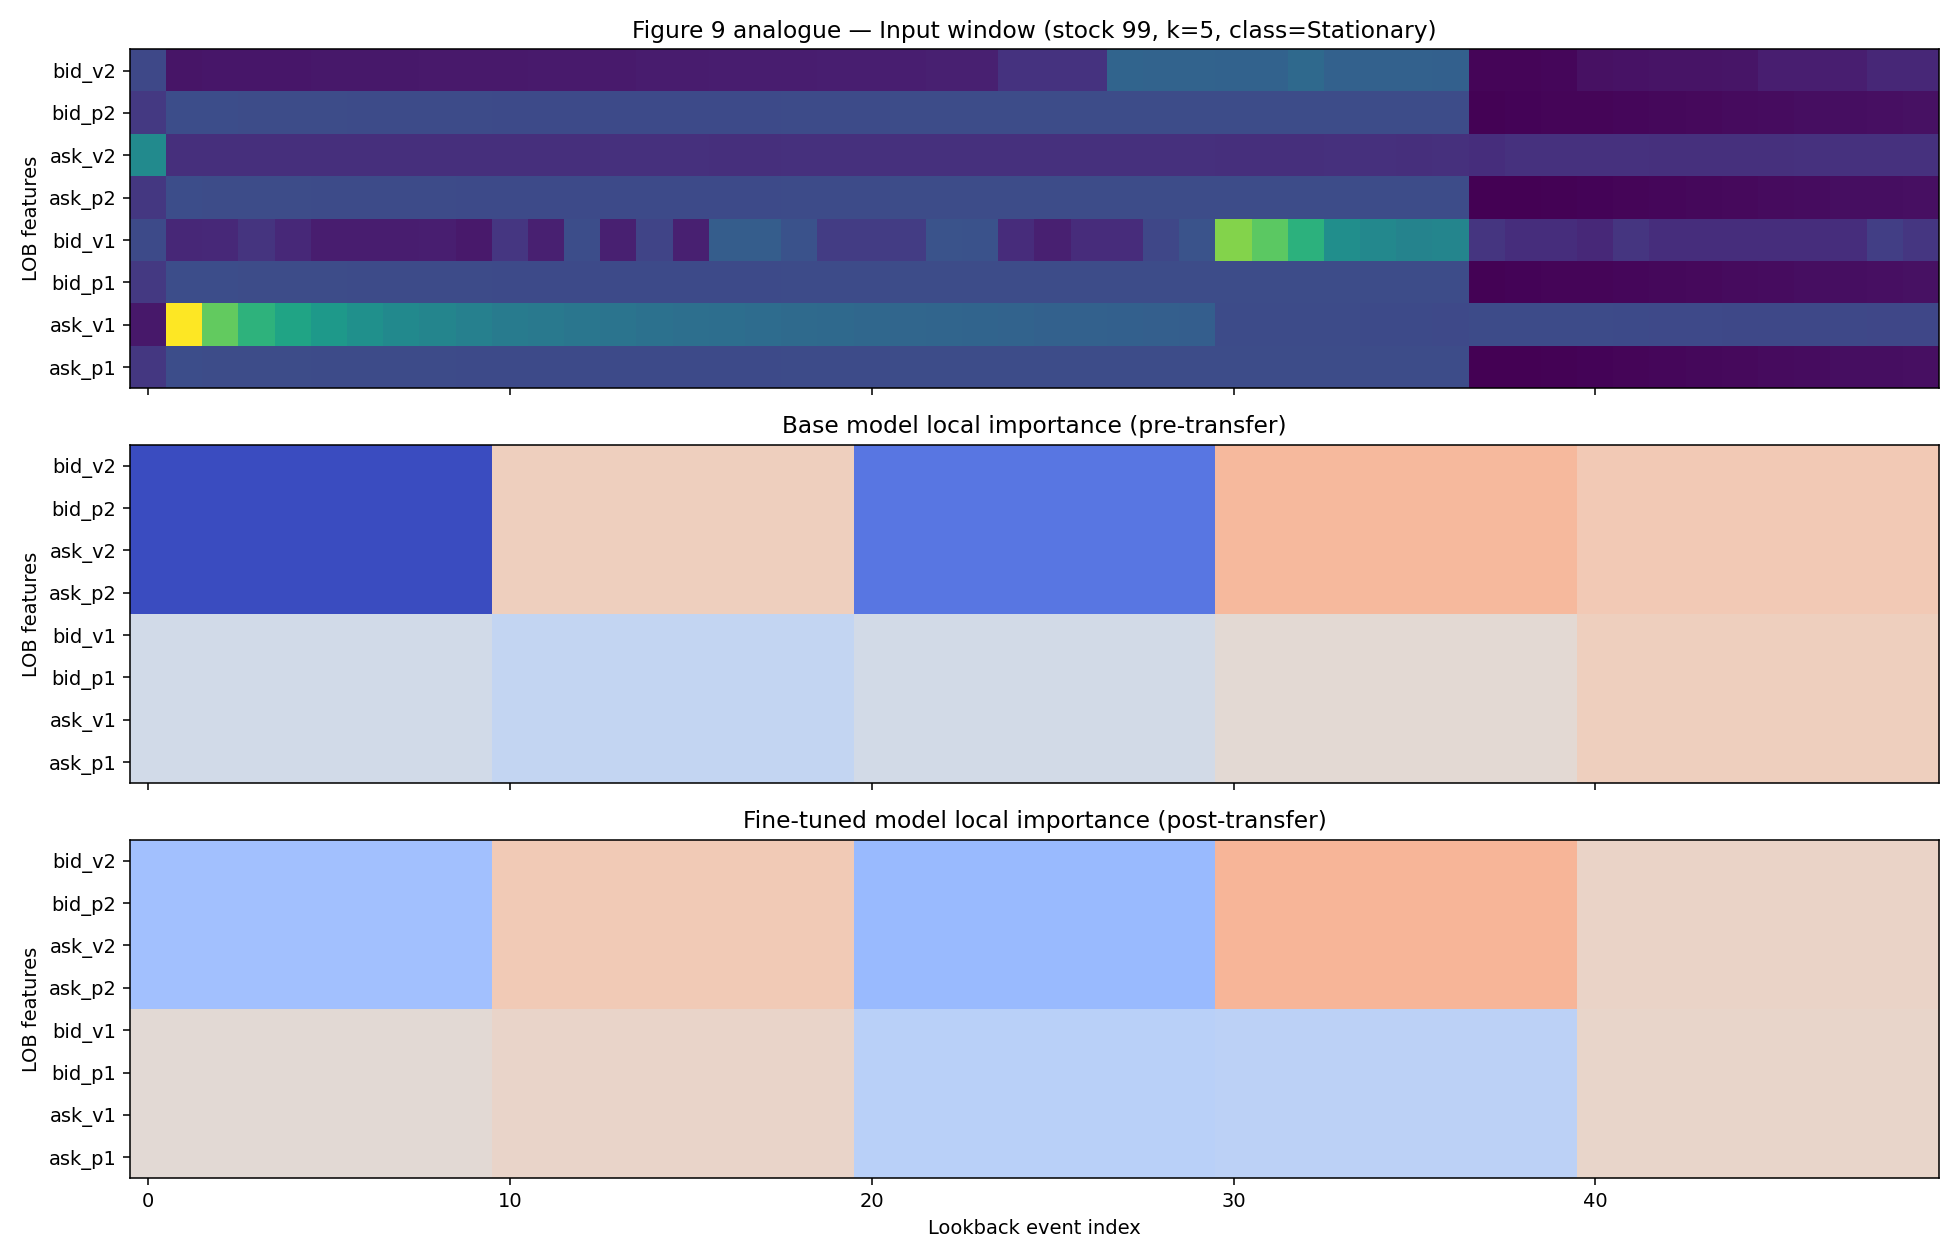

In [ ]:
if (RESULT_DIR / 'curated_transfer_accuracy_k5.png').exists():
    figure_names = [
        'curated_transfer_accuracy_k5.png',
        'transfer_comparison_k5.png',
        'transfer_regimes_k5.png',
    ]
else:
    figure_names = [
        'figure6_transfer_accuracy.png',
        'figure7_transfer_profit_tstats.png',
        'figure8_transfer_cum_profit.png',
        'figure9_transfer_lime.png',
    ]
for name in figure_names:
    path = RESULT_DIR / name
    print(name)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print('  not available yet.')


## 11. Interpretation

The cleaned Optiver report keeps only one transfer-learning slice.

- The report horizon is **k = 5**.
- The retained held-out stocks are **5, 17, 42, 108, 120**.
- `transfer_comparison_k5.png`, `transfer_regimes_k5.png`, and `transfer_loss_selected_k5.png` summarize the retained transfer behavior on that slice.
- `specific_metrics_k5.pkl` keeps the same-stock temporal out-of-sample reference for the same retained stocks.
- Dropped horizons, dropped stocks, and intermediate comparison artifacts are no longer part of the active project surface.

The final Optiver question is therefore no longer “which horizon or stock should be kept?” but simply “how strong is the retained cross-stock transfer configuration on the final kept slice?”

In [13]:
if summary_path.exists():
    summary = json.loads(summary_path.read_text())
    df_summary = pd.DataFrame(summary['per_stock_horizon'])
    best = df_summary.sort_values('accuracy_delta', ascending=False).iloc[0]
    worst = df_summary.sort_values('accuracy_delta', ascending=True).iloc[0]
    print('Best transfer improvement:')
    display(best.to_frame().T)
    print('Weakest transfer improvement:')
    display(worst.to_frame().T)
    if 'lime_case' in summary:
        print('Figure 9 example case:', summary['lime_case'])
else:
    print('Interpretation summary will be available after the cluster job finishes.')

Best transfer improvement:


,stock_id,horizon_k,accuracy_before,accuracy_after,accuracy_delta,profit_before_mean,profit_after_mean,profit_delta
6,99.0,5.0,0.438333,0.447778,0.009444,0.070627,0.072151,0.001523


Weakest transfer improvement:


,stock_id,horizon_k,accuracy_before,accuracy_after,accuracy_delta,profit_before_mean,profit_after_mean,profit_delta
10,90.0,10.0,0.526667,0.502778,-0.023889,0.115279,0.065903,-0.049376


Figure 9 example case: {'stock_id': 99, 'horizon_k': 5, 'sample_index': 1264, 'true_class': 'Stationary'}


## Final Report Update — Original3 vs Rolling3

This section is the **authoritative Optiver final report surface** for the current retained workflow. The project now keeps two classification-only variants over the same retained `k = 5` transfer-learning problem:

- **Original3**: the preprocessing-time adaptive threshold labels, preserved for semantic continuity with the original Optiver label design.
- **Rolling3**: a rolling historical quantile relabeling scheme, designed to keep the target distribution closer to a controlled `0.4 / 0.2 / 0.4` split without leaking future information into the current threshold.

Both branches share the same backbone and training protocol: 2-level DeepLOBLite input (`8` features), lookback `T = 50`, focal-loss training, volatility-stratified base sampling, and the same transfer-learning machinery. What changes is the label construction and, as a consequence, the balance ranking of the held-out transfer stocks.

### How to read the results correctly

For this kind of microstructure classification task, **accuracy alone is not enough**:

- A model can achieve acceptable accuracy by over-predicting the dominant class.
- The easiest class is often the most frequent one, so raw accuracy can hide collapse on the harder directional classes.
- Transfer-learning can improve session-normalized profit or prediction diversity even when hard-label accuracy does not improve.

The report therefore uses **macro-F1, Cohen's $\kappa$, MCC, dominant-class share, normalized entropy, zero-shot vs. transfer deltas, and profit-style session summaries** together. These are the diagnostics that determine whether a model is merely matching class priors or actually learning a transferable directional representation.

In [1]:
from pathlib import Path
import json, pickle
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

BASE_DIR = Path('/ocean/projects/mth250011p/xxiao7/DeepLOB')
OPTIVER_FINAL_DIRS = {
    'Original3': BASE_DIR / 'results' / 'optiver' / 'classification_original3',
    'Rolling3': BASE_DIR / 'results' / 'optiver' / 'classification_rolling3_w20000',
}

def load_optiver_variant(result_dir: Path):
    base_metrics = pickle.load(open(result_dir / 'base_metrics_k5.pkl', 'rb'))
    summary = json.load(open(result_dir / 'transfer_analysis_summary.json'))
    per_stock = pd.DataFrame(summary.get('per_stock_horizon', []))
    diagnostic_rows = []
    for item in summary.get('strategy_diagnostics', []):
        selected_mode = item.get('selected_transfer_mode', item.get('requested_transfer_mode'))
        selected_candidate = None
        for candidate in item.get('candidate_modes', []):
            if candidate.get('transfer_mode') == selected_mode:
                selected_candidate = candidate
                break
        if selected_candidate is None and item.get('candidate_modes'):
            selected_candidate = item['candidate_modes'][0]
        if selected_candidate is None:
            continue
        test_metrics = selected_candidate.get('test_metrics', {})
        prediction_summary = selected_candidate.get('prediction_summary', {})
        diagnostic_rows.append({
            'stock_id': item.get('stock_id'),
            'selected_mode': selected_mode,
            'val_macro_f1': float(selected_candidate.get('best_val_macro_f1', np.nan)),
            'test_accuracy': float(test_metrics.get('accuracy', np.nan)),
            'test_kappa': float(test_metrics.get('kappa', np.nan)),
            'test_mcc': float(test_metrics.get('mcc', np.nan)),
            'weighted_f1': float(test_metrics.get('f1_w', np.nan)),
            'dominant_label': prediction_summary.get('dominant_label'),
            'dominant_share': float(prediction_summary.get('dominant_share', np.nan)),
            'normalized_entropy': float(prediction_summary.get('normalized_entropy', np.nan)),
        })
    diagnostics = pd.DataFrame(diagnostic_rows)
    overview = {
        'variant': result_dir.name,
        'label_mode': base_metrics.get('label_mode'),
        'num_classes': base_metrics.get('num_classes'),
        'class_names': ', '.join(base_metrics.get('class_names', [])),
        'quantile_stationary': base_metrics.get('quantile_stationary'),
        'rolling_window': base_metrics.get('rolling_quantile_window'),
        'n_transfer_stocks': len(per_stock),
        'mean_acc_before': float(per_stock['accuracy_before'].mean()),
        'mean_acc_after': float(per_stock['accuracy_after'].mean()),
        'mean_profit_before': float(per_stock['profit_before_mean'].mean()),
        'mean_profit_after': float(per_stock['profit_after_mean'].mean()),
    }
    return overview, per_stock, diagnostics

variant_overview = []
variant_stock_tables = []
variant_diag_tables = []
per_stock_lookup = {}
for variant_name, result_dir in OPTIVER_FINAL_DIRS.items():
    overview, per_stock, diagnostics = load_optiver_variant(result_dir)
    overview['variant_name'] = variant_name
    variant_overview.append(overview)
    per_stock = per_stock.copy()
    per_stock['variant'] = variant_name
    variant_stock_tables.append(per_stock)
    per_stock_lookup[variant_name] = per_stock.set_index('stock_id')
    if not diagnostics.empty:
        diagnostics = diagnostics.copy()
        diagnostics['variant'] = variant_name
        variant_diag_tables.append(diagnostics)

overview_df = pd.DataFrame(variant_overview)[['variant_name', 'label_mode', 'num_classes', 'quantile_stationary', 'rolling_window', 'n_transfer_stocks', 'mean_acc_before', 'mean_acc_after', 'mean_profit_before', 'mean_profit_after']]
per_stock_df = pd.concat(variant_stock_tables, ignore_index=True)[['variant', 'stock_id', 'selected_transfer_mode', 'accuracy_before', 'accuracy_after', 'accuracy_delta', 'profit_before_mean', 'profit_after_mean', 'profit_delta', 'base_dominant_label', 'base_dominant_share', 'transfer_dominant_label', 'transfer_dominant_share']]
diag_df = pd.concat(variant_diag_tables, ignore_index=True)[['variant', 'stock_id', 'selected_mode', 'val_macro_f1', 'test_accuracy', 'test_kappa', 'test_mcc', 'weighted_f1', 'dominant_label', 'dominant_share', 'normalized_entropy']]

display(Markdown('### Variant-level overview'))
display(overview_df.round(4))

display(Markdown('### Per-stock transfer summary'))
display(per_stock_df.round(4))

display(Markdown('### Selected transfer-mode diagnostics'))
display(diag_df.round(4))

shared_stocks = sorted(set(per_stock_lookup['Original3'].index) & set(per_stock_lookup['Rolling3'].index))
if shared_stocks:
    shared_rows = []
    for stock_id in shared_stocks:
        row_orig = per_stock_lookup['Original3'].loc[stock_id]
        row_roll = per_stock_lookup['Rolling3'].loc[stock_id]
        shared_rows.append({
            'stock_id': stock_id,
            'orig3_acc_after': float(row_orig['accuracy_after']),
            'rolling3_acc_after': float(row_roll['accuracy_after']),
            'orig3_profit_after': float(row_orig['profit_after_mean']),
            'rolling3_profit_after': float(row_roll['profit_after_mean']),
        })
    display(Markdown('### Shared-stock comparison (only directly comparable names, not the full selected-stock sets)'))
    display(pd.DataFrame(shared_rows).round(4))

### Variant-level overview

,variant_name,label_mode,num_classes,quantile_stationary,rolling_window,n_transfer_stocks,mean_acc_before,mean_acc_after,mean_profit_before,mean_profit_after
0,Original3,original,3,0.2,None,5,0.4375,0.4219,0.0483,0.0399
1,Rolling3,rolling-quantile-3class,3,0.2,None,3,0.4281,0.4110,0.0675,0.0674


### Per-stock transfer summary

,variant,stock_id,selected_transfer_mode,accuracy_before,accuracy_after,accuracy_delta,profit_before_mean,profit_after_mean,profit_delta,base_dominant_label,base_dominant_share,transfer_dominant_label,transfer_dominant_share
0,Original3,5,all,0.3909,0.3995,0.0086,0.0634,0.0401,-0.0233,Up,0.3835,Down,0.3477
1,Original3,17,all,0.3699,0.3724,0.0025,0.0012,-0.0060,-0.0073,Up,0.5265,Up,0.4229
2,Original3,42,lstm_conv3,0.3983,0.3921,-0.0062,0.1181,0.0532,-0.0650,Up,0.4488,Up,0.3933
3,Original3,108,lstm_conv3,0.6301,0.5524,-0.0777,0.0047,0.0651,0.0604,Stationary,0.7978,Stationary,0.5240
4,Original3,120,lstm_conv3,0.3983,0.3933,-0.0049,0.0541,0.0470,-0.0071,Up,0.3810,Up,0.3711
5,Rolling3,42,lstm_conv3,0.4196,0.4044,-0.0152,0.0348,0.0491,0.0144,Down,0.4589,Up,0.3856
6,Rolling3,17,lstm_conv3,0.4337,0.4033,-0.0304,0.0788,0.0571,-0.0218,Down,0.5159,Up,0.3859
7,Rolling3,82,lstm_conv3,0.4311,0.4252,-0.0059,0.0890,0.0960,0.0070,Down,0.4367,Up,0.4326


### Selected transfer-mode diagnostics

,variant,stock_id,selected_mode,val_macro_f1,test_accuracy,test_kappa,test_mcc,weighted_f1,dominant_label,dominant_share,normalized_entropy
0,Original3,5,all,0.3691,0.3995,0.0988,0.0988,0.3996,Down,0.3477,0.9995
1,Original3,17,all,0.3924,0.3724,0.0517,0.0520,0.3708,Up,0.4229,0.9798
2,Original3,42,lstm_conv3,0.4059,0.3921,0.0857,0.0859,0.3909,Up,0.3933,0.9928
3,Original3,108,lstm_conv3,0.5182,0.5524,0.2454,0.2475,0.5635,Stationary,0.5240,0.9242
4,Original3,120,lstm_conv3,0.4420,0.3933,0.0895,0.0896,0.3933,Up,0.3711,0.9968
5,Rolling3,42,lstm_conv3,0.3816,0.4044,0.0752,0.0754,0.4078,Up,0.3856,0.9769
6,Rolling3,17,lstm_conv3,0.3490,0.4033,0.0841,0.0849,0.4088,Up,0.3859,0.9901
7,Rolling3,82,lstm_conv3,0.3885,0.4252,0.0938,0.0939,0.4242,Up,0.4326,0.9463


### Shared-stock comparison (only directly comparable names, not the full selected-stock sets)

,stock_id,orig3_acc_after,rolling3_acc_after,orig3_profit_after,rolling3_profit_after
0,17,0.3724,0.4033,-0.0060,0.0571
1,42,0.3921,0.4044,0.0532,0.0491


### Technical Interpretation and Model-Selection Logic

The two retained variants answer **different technical questions**, so they should not be collapsed into a single accuracy ranking.

**1. Original3 is the semantic-continuity branch.** It keeps the original adaptive-threshold labels and therefore preserves the exact meaning of the preprocessing-time Optiver target. On its five selected transfer stocks, the zero-shot model already reaches an average accuracy of roughly `0.4375`, but the average post-transfer accuracy falls to about `0.4219`, and the average profit-style session score also declines. This is a warning sign: transfer learning is not automatically helpful when the underlying label distribution is highly stock-specific.

**2. Rolling3 is the imbalance-controlled branch.** By reconstructing the stationary threshold from a rolling historical quantile, the target distribution on the balanced study stocks is much closer to the intended `0.4 / 0.2 / 0.4` profile. The model therefore operates on a less distorted supervision signal. Its average post-transfer accuracy on the three selected stocks is lower than its zero-shot accuracy (`0.4110` vs. `0.4281`), but the average profit-style score is nearly unchanged, and two of the three stocks improve in profit after transfer. That is exactly the kind of divergence that makes a single-metric evaluation unsafe.

**3. Accuracy is not the decisive metric in this task.** The notebook should always interpret the following diagnostics together:

- **Macro-F1**: whether all classes are being learned rather than only the dominant one.
- **Cohen's $\kappa$ and MCC**: whether the model is meaningfully better than a class-prior-matching classifier.
- **Dominant prediction share and normalized entropy**: whether the prediction distribution has collapsed toward one class.
- **Profit-style session diagnostics**: whether the directional errors matter economically, not just categorically.

**4. The selected transfer-stock sets differ across variants.** That means the mean metrics in the overview table are within-variant summaries, not a perfect apples-to-apples leaderboard. The shared-stock table is the fairer cross-variant stress test. On the shared stocks, Rolling3 finishes with stronger post-transfer accuracy than Original3, which supports the claim that the rolling relabeling is improving robustness rather than simply reshuffling class priors.

**5. Practical interpretation for the final write-up.**

- Use **Original3** when you want the report to remain faithful to the original label semantics.
- Use **Rolling3** when you want the cleaner imbalance-controlled stress test and a stronger defense against dominant-class inflation.
- In both cases, any claim of transfer improvement must be defended by more than accuracy alone. The confusion matrices, macro-F1 / $\kappa$ / MCC diagnostics, prediction entropy, and profit-style curves are mandatory evidence.

### Original3 figure gallery

**Base training loss and monitor trajectory**  \n`base_loss_k5.png`

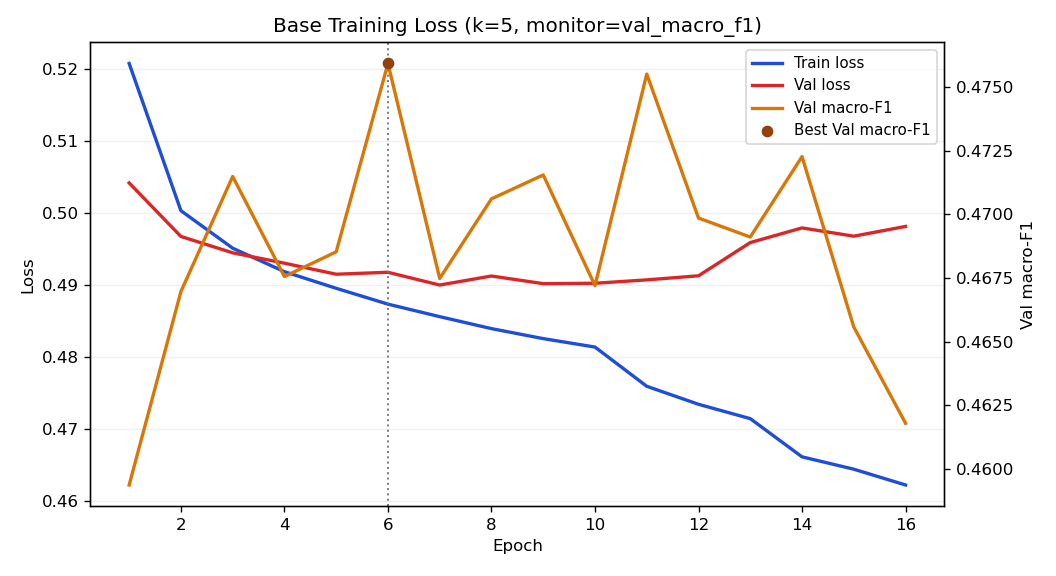

**Base-model confusion matrix on held-out stocks**  \n`cm_base_k5.png`

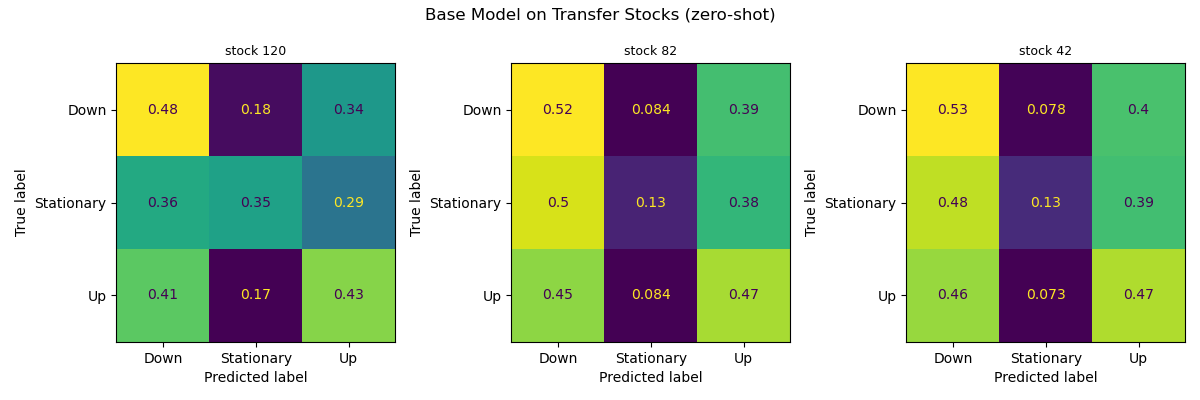

**Before/after transfer comparison on selected stocks**  \n`transfer_comparison_k5.png`

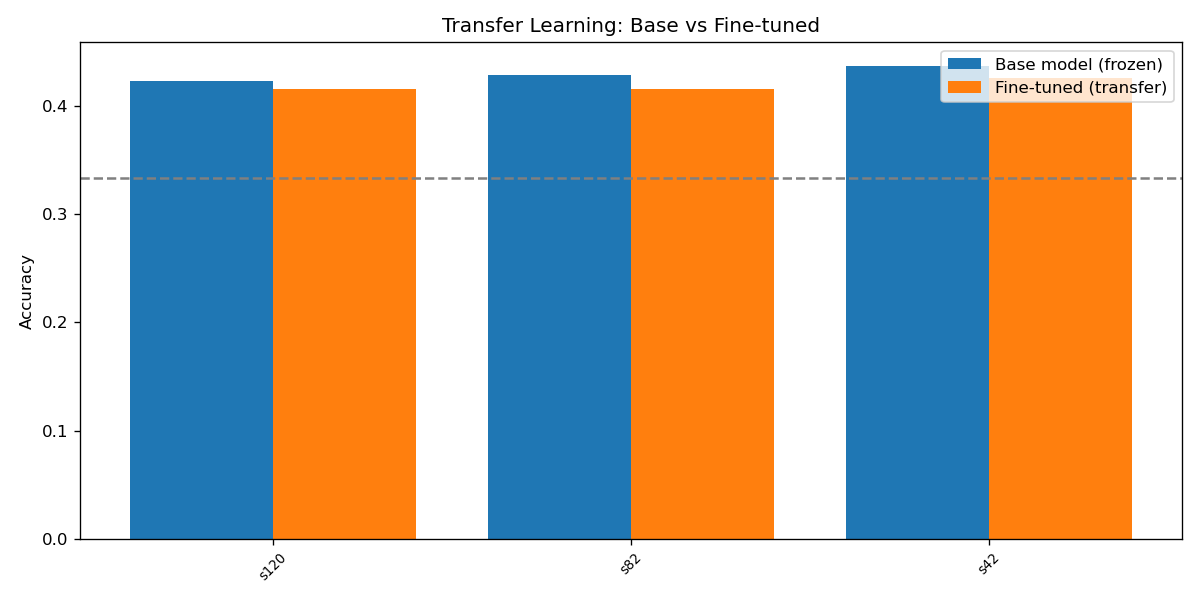

**Transfer-mode comparison across the selected stocks**  \n`transfer_regimes_k5.png`

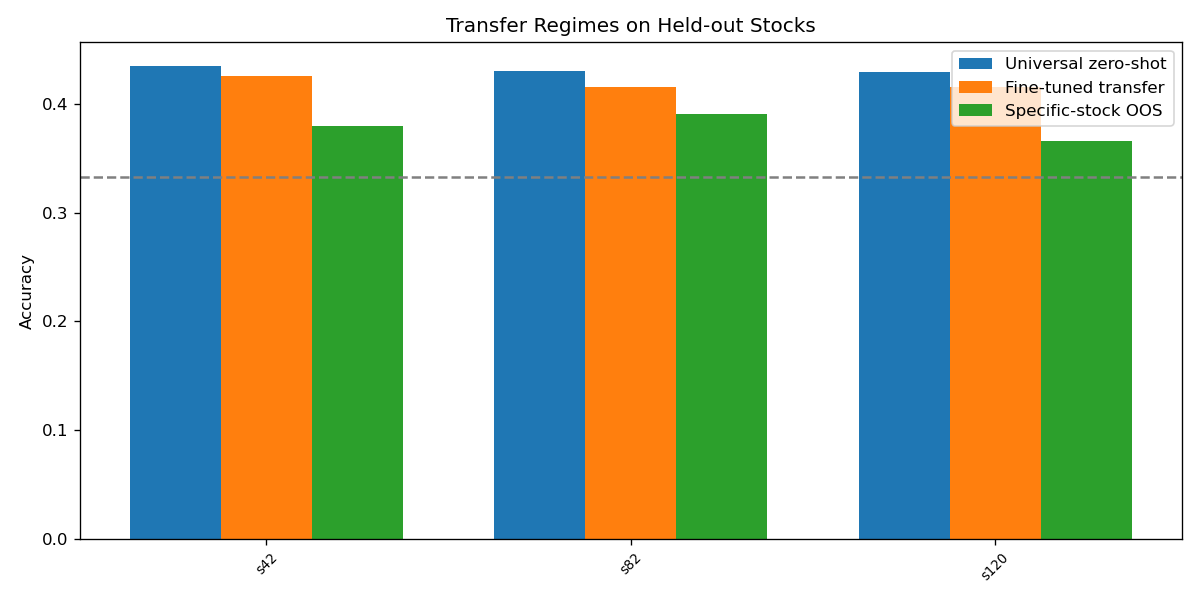

**Per-session transfer accuracy diagnostic**  \n`figure6_transfer_accuracy.png`

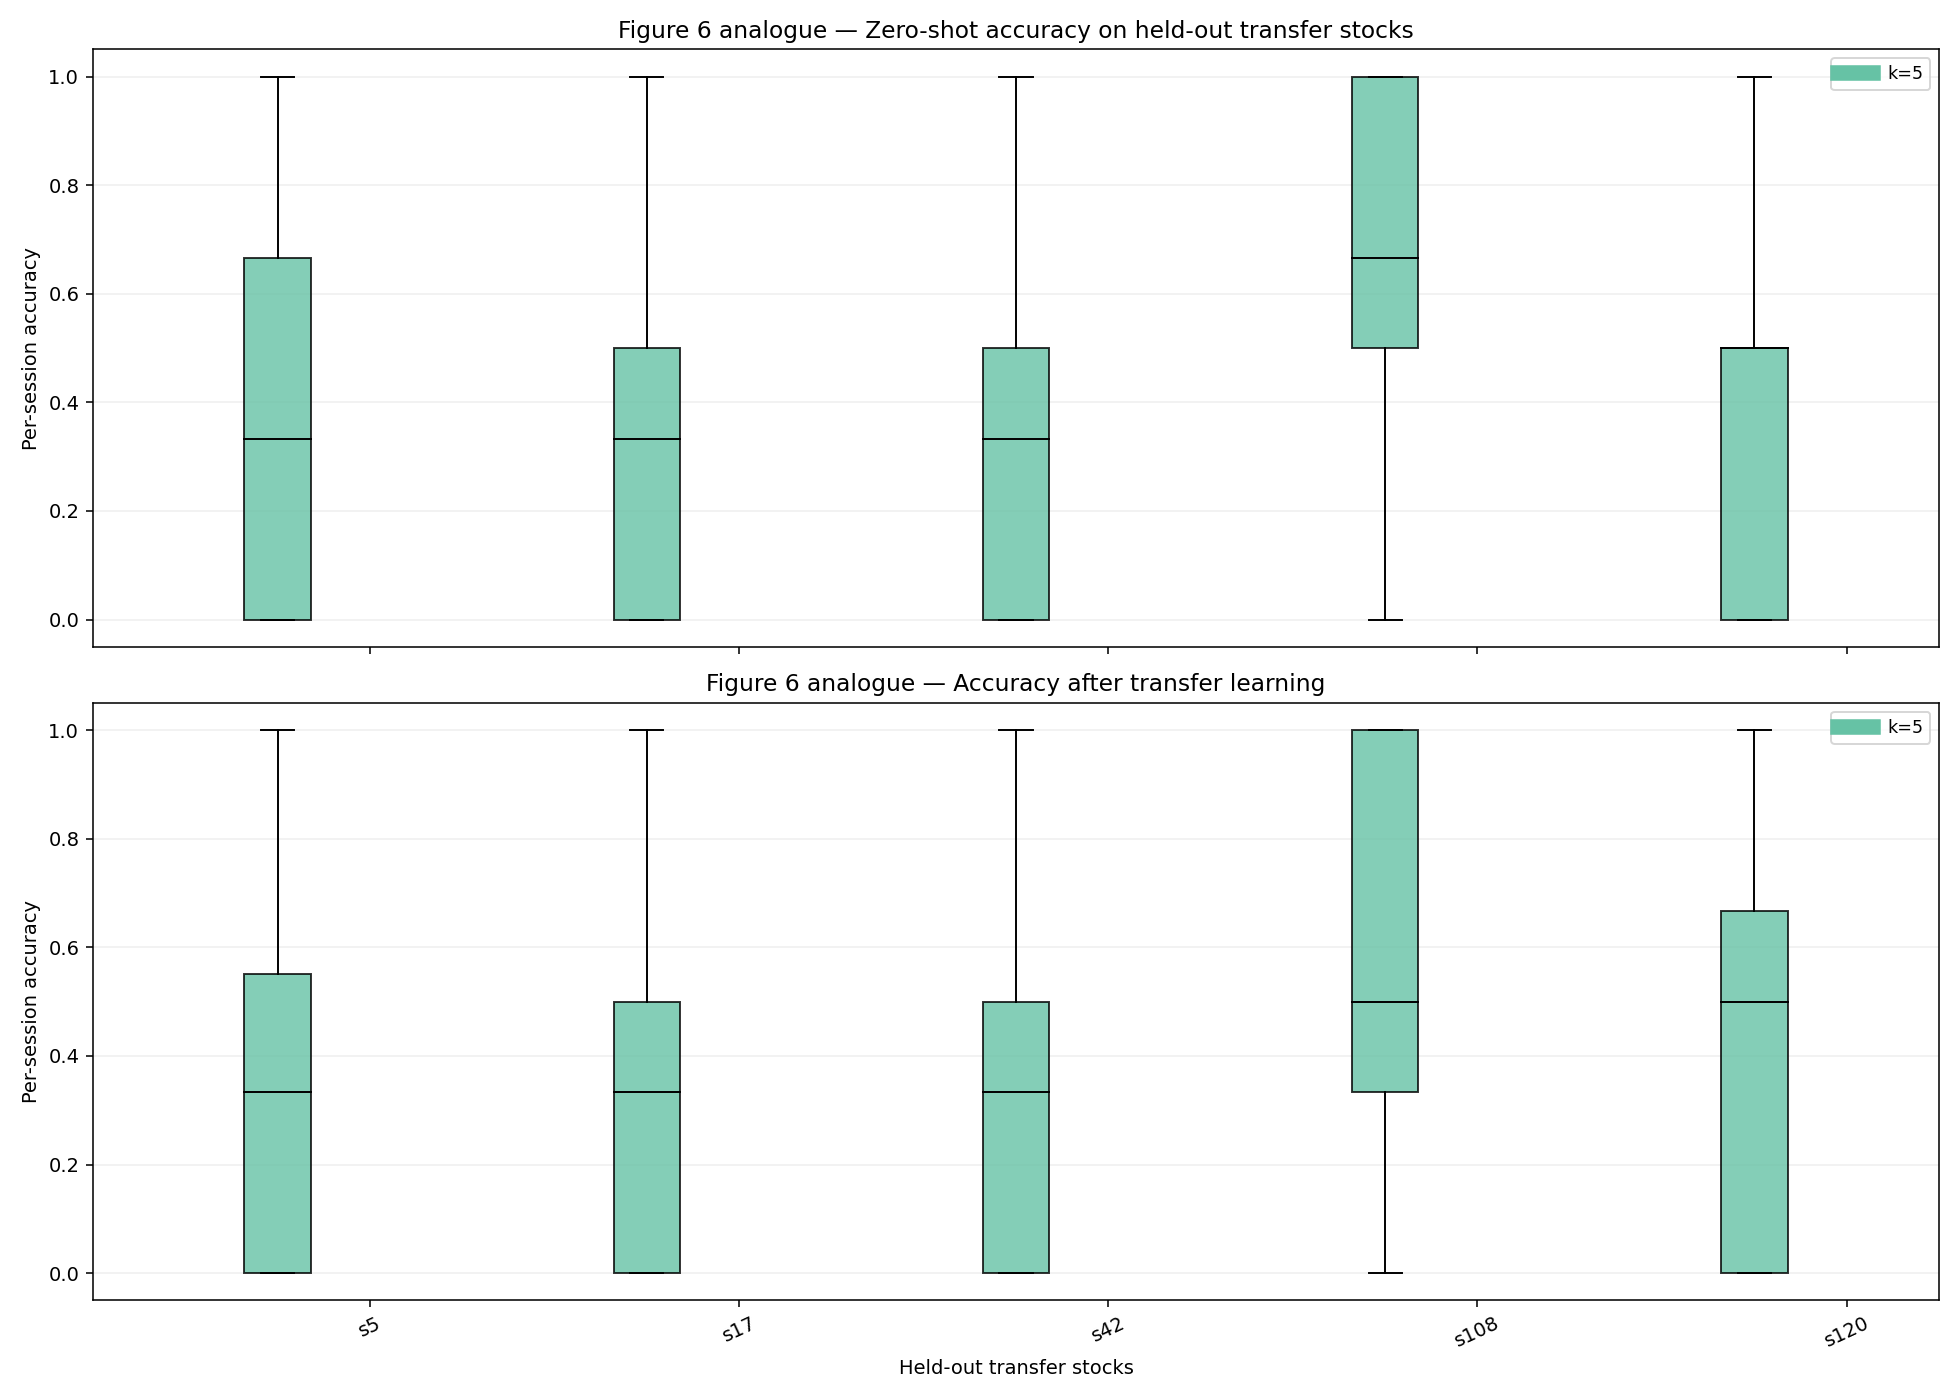

**Profit-style session t-statistic diagnostic**  \n`figure7_transfer_profit_tstats.png`

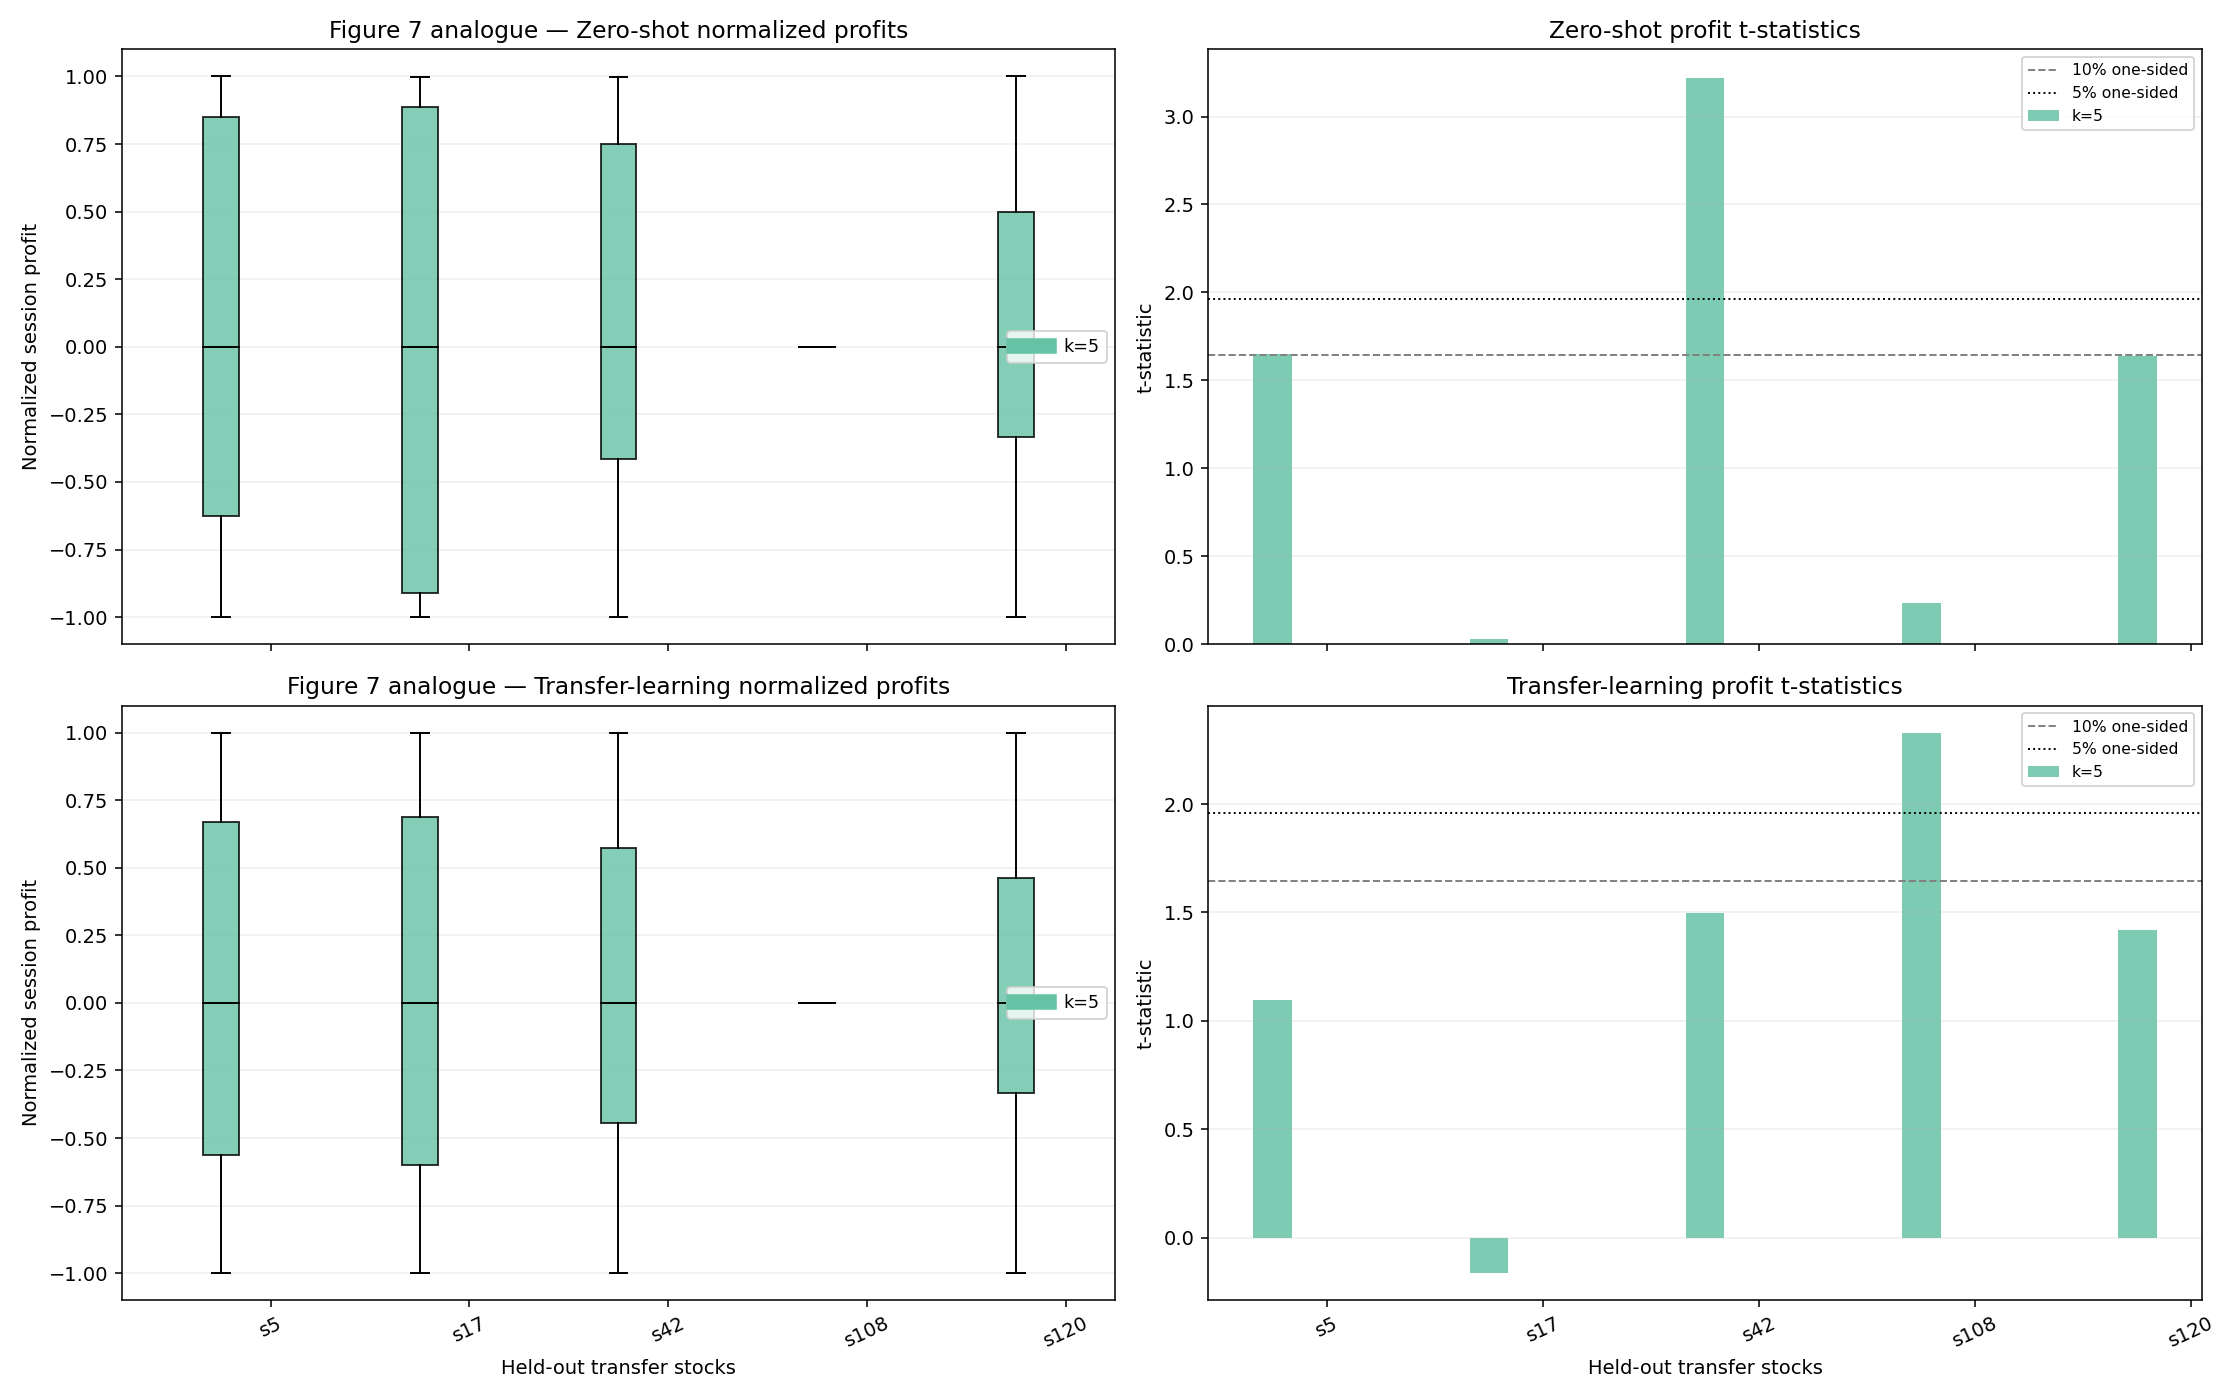

**Cumulative normalized profit curves**  \n`figure8_transfer_cum_profit.png`

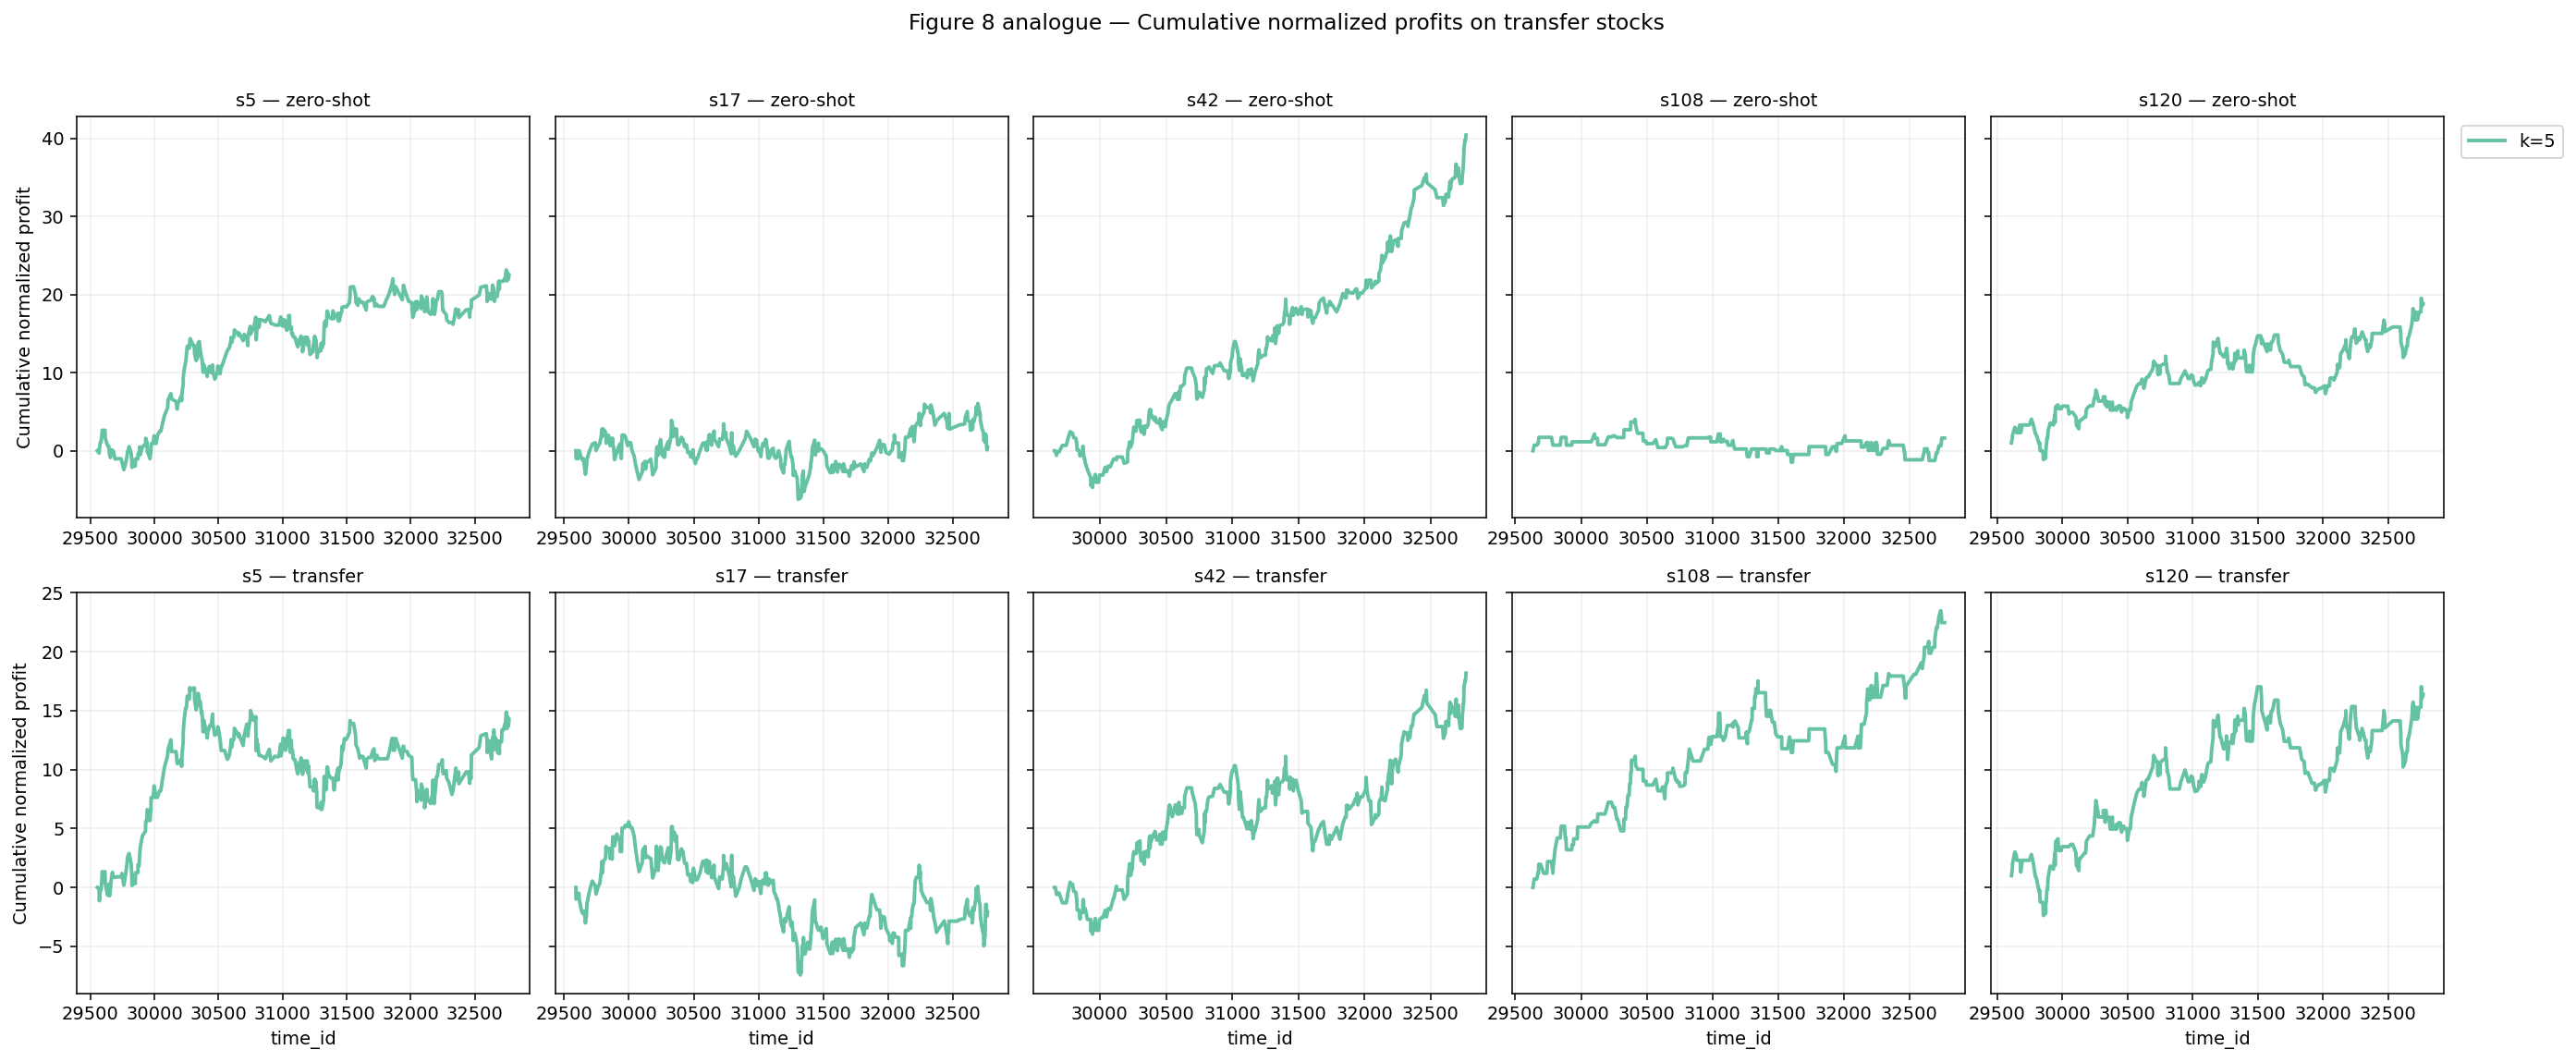

**LIME-style local explanation case**  \n`figure9_transfer_lime.png`

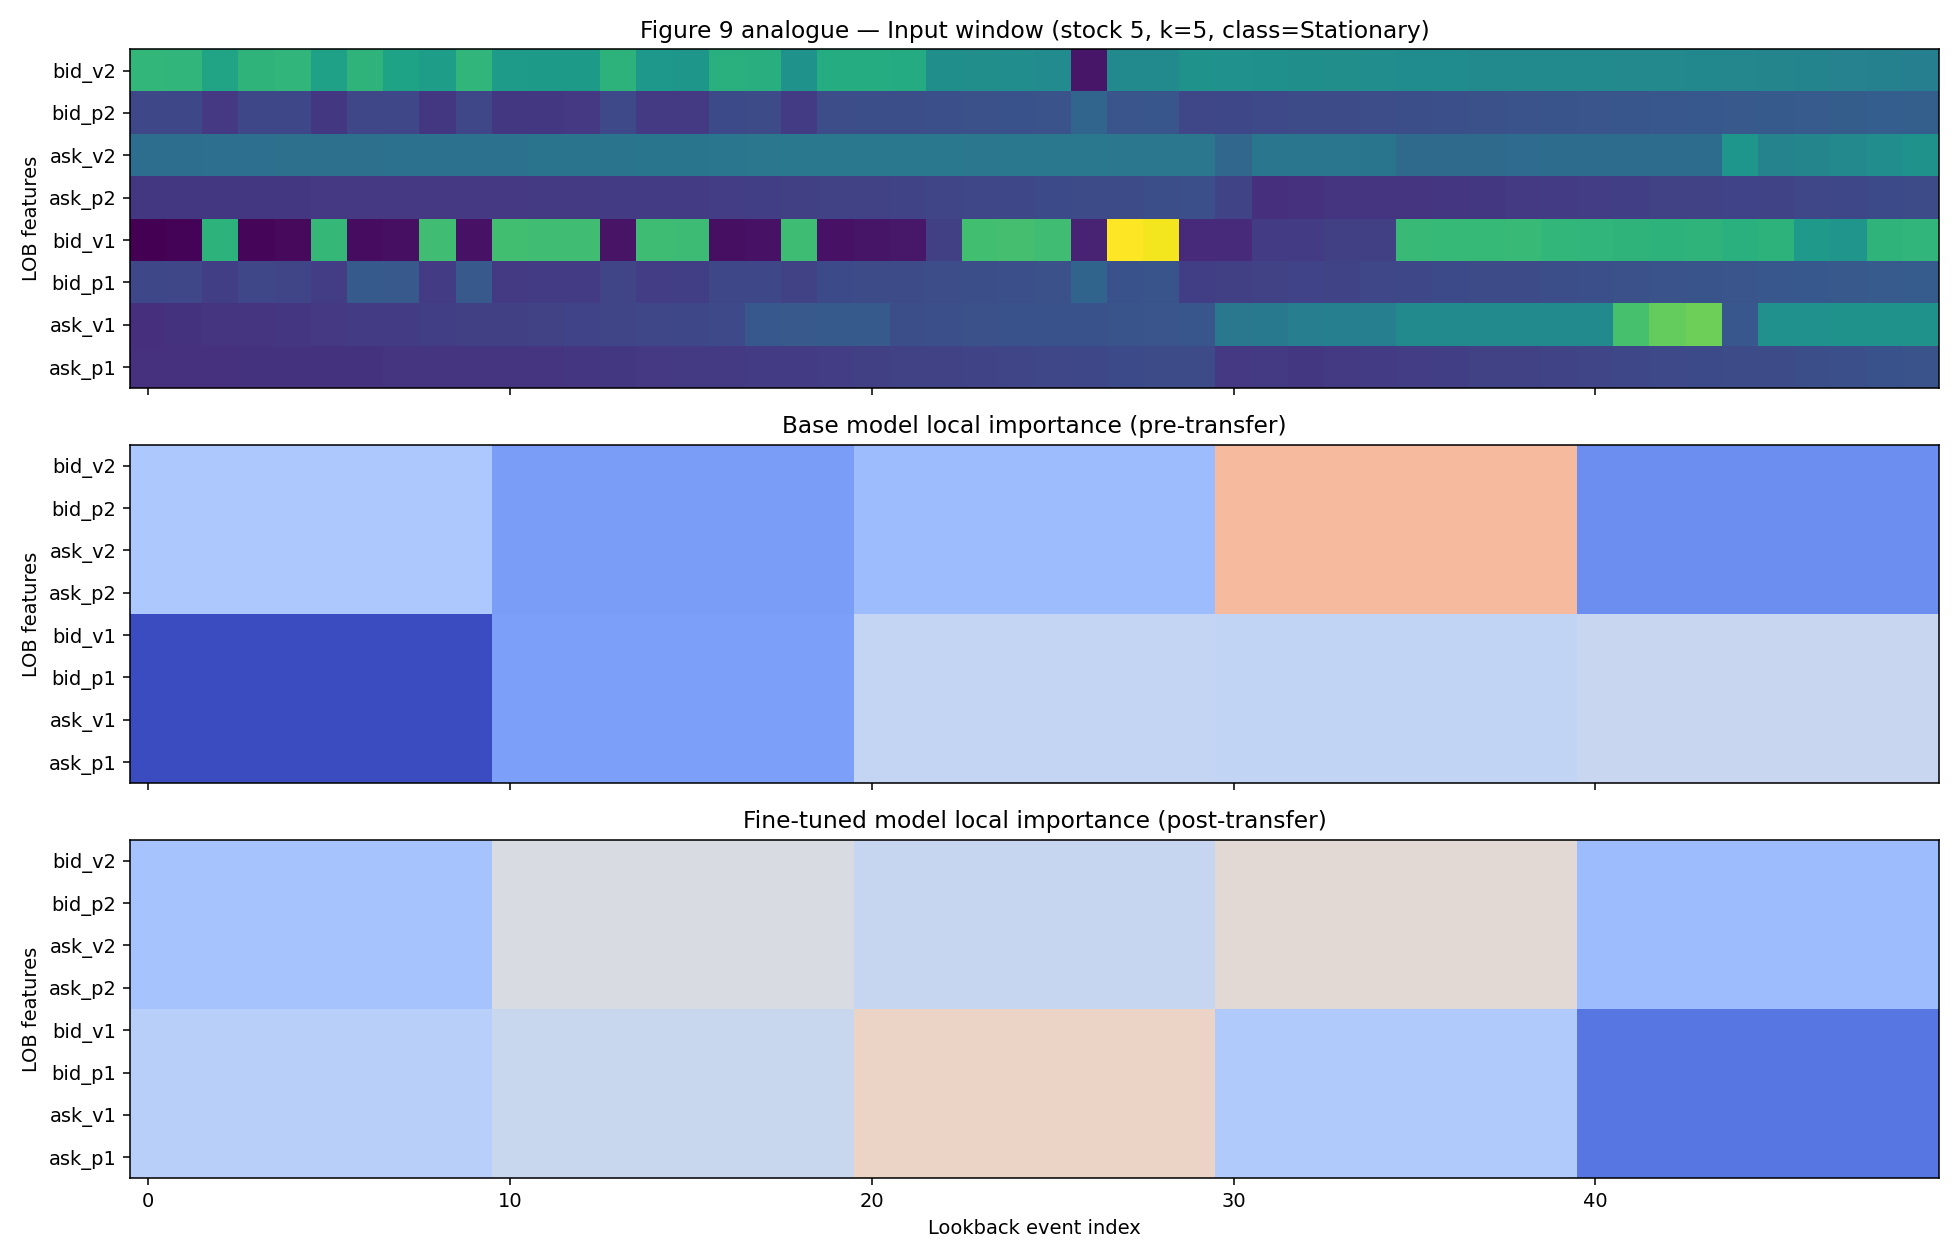

### Rolling3 figure gallery

**Base training loss and monitor trajectory**  \n`base_loss_k5.png`

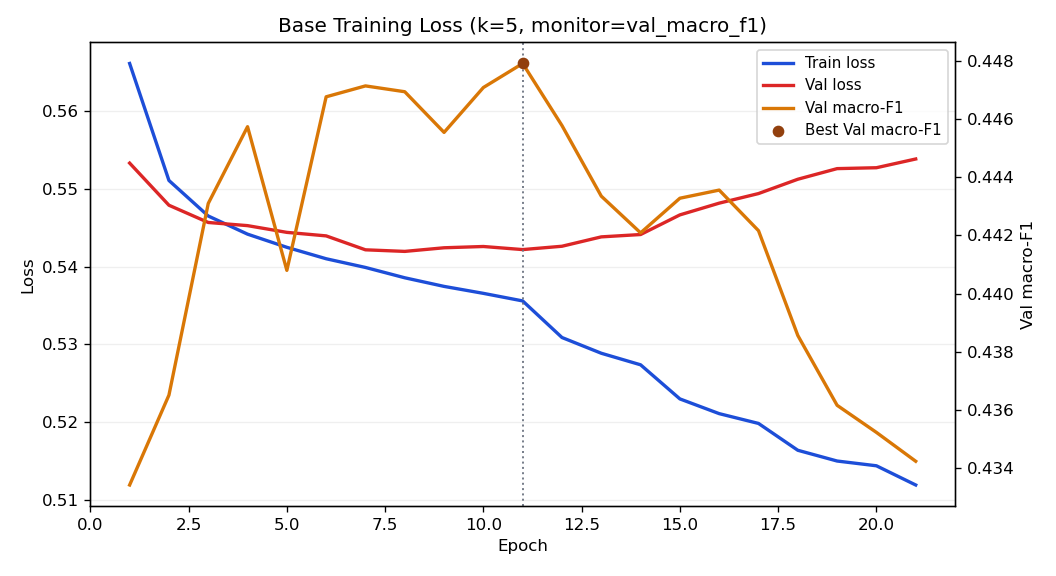

**Base-model confusion matrix on held-out stocks**  \n`cm_base_k5.png`

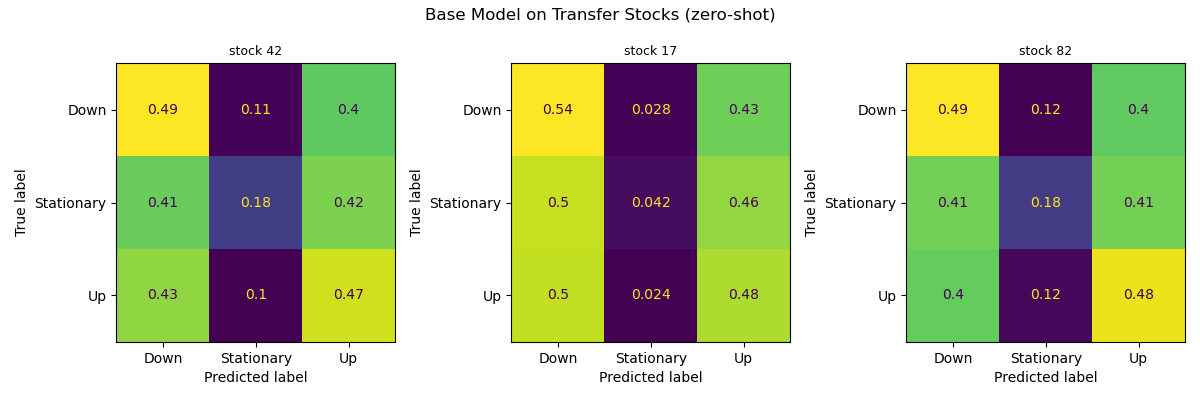

**Before/after transfer comparison on selected stocks**  \n`transfer_comparison_k5.png`

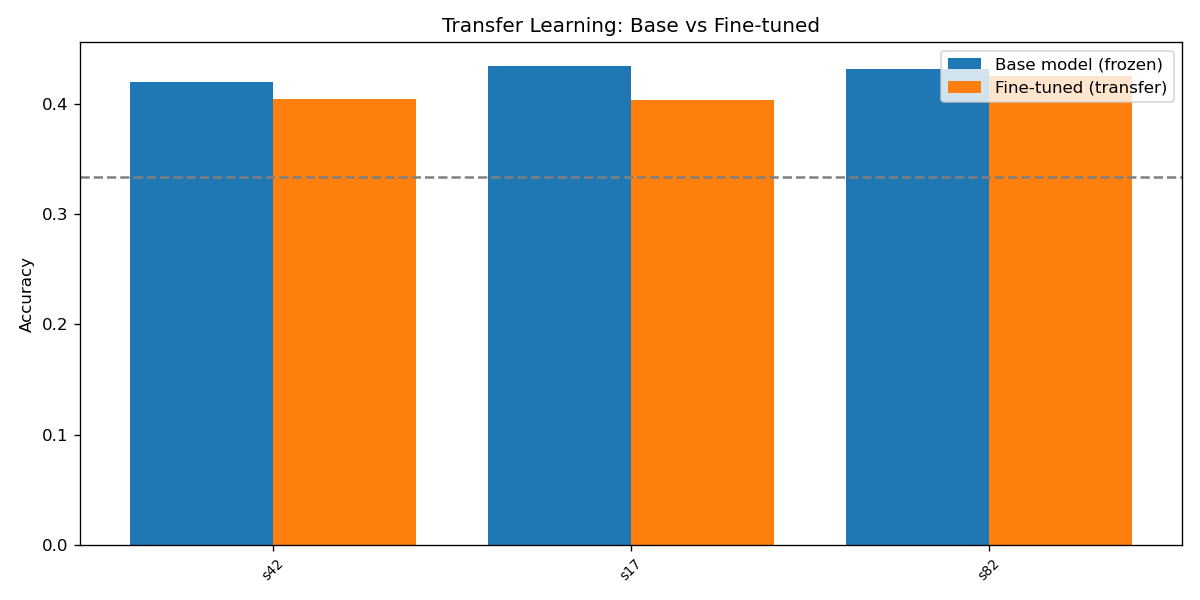

**Transfer-mode comparison across the selected stocks**  \n`transfer_regimes_k5.png`

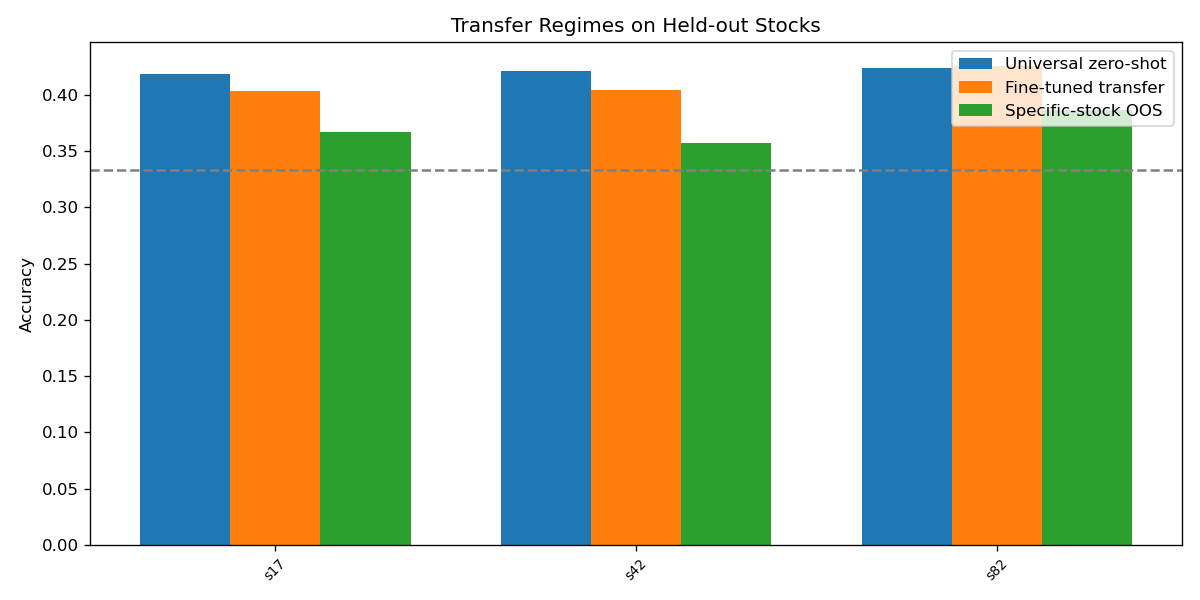

**Per-session transfer accuracy diagnostic**  \n`figure6_transfer_accuracy.png`

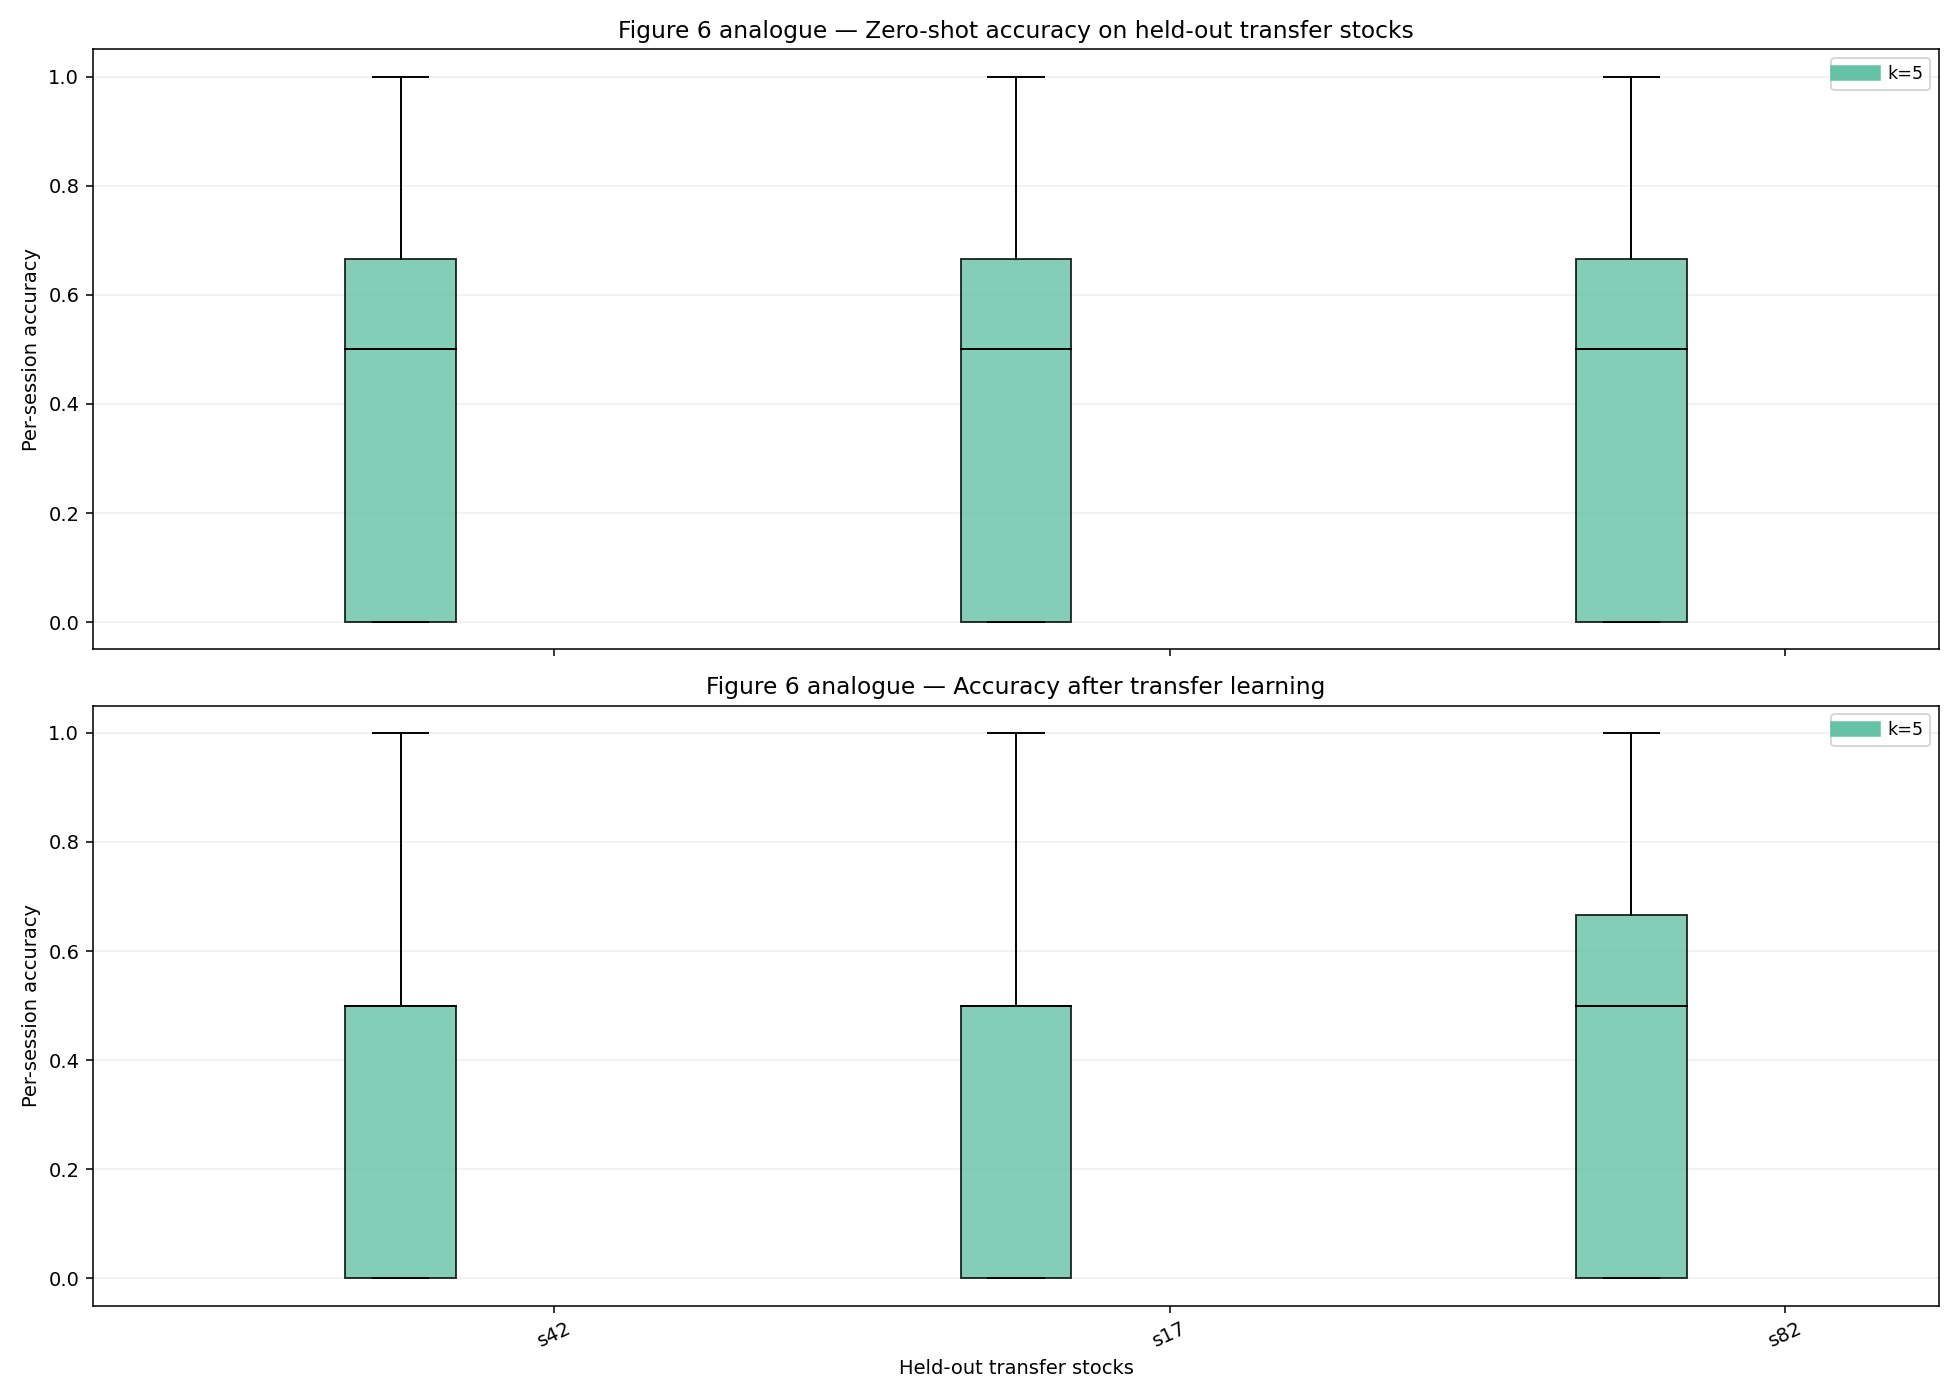

**Profit-style session t-statistic diagnostic**  \n`figure7_transfer_profit_tstats.png`

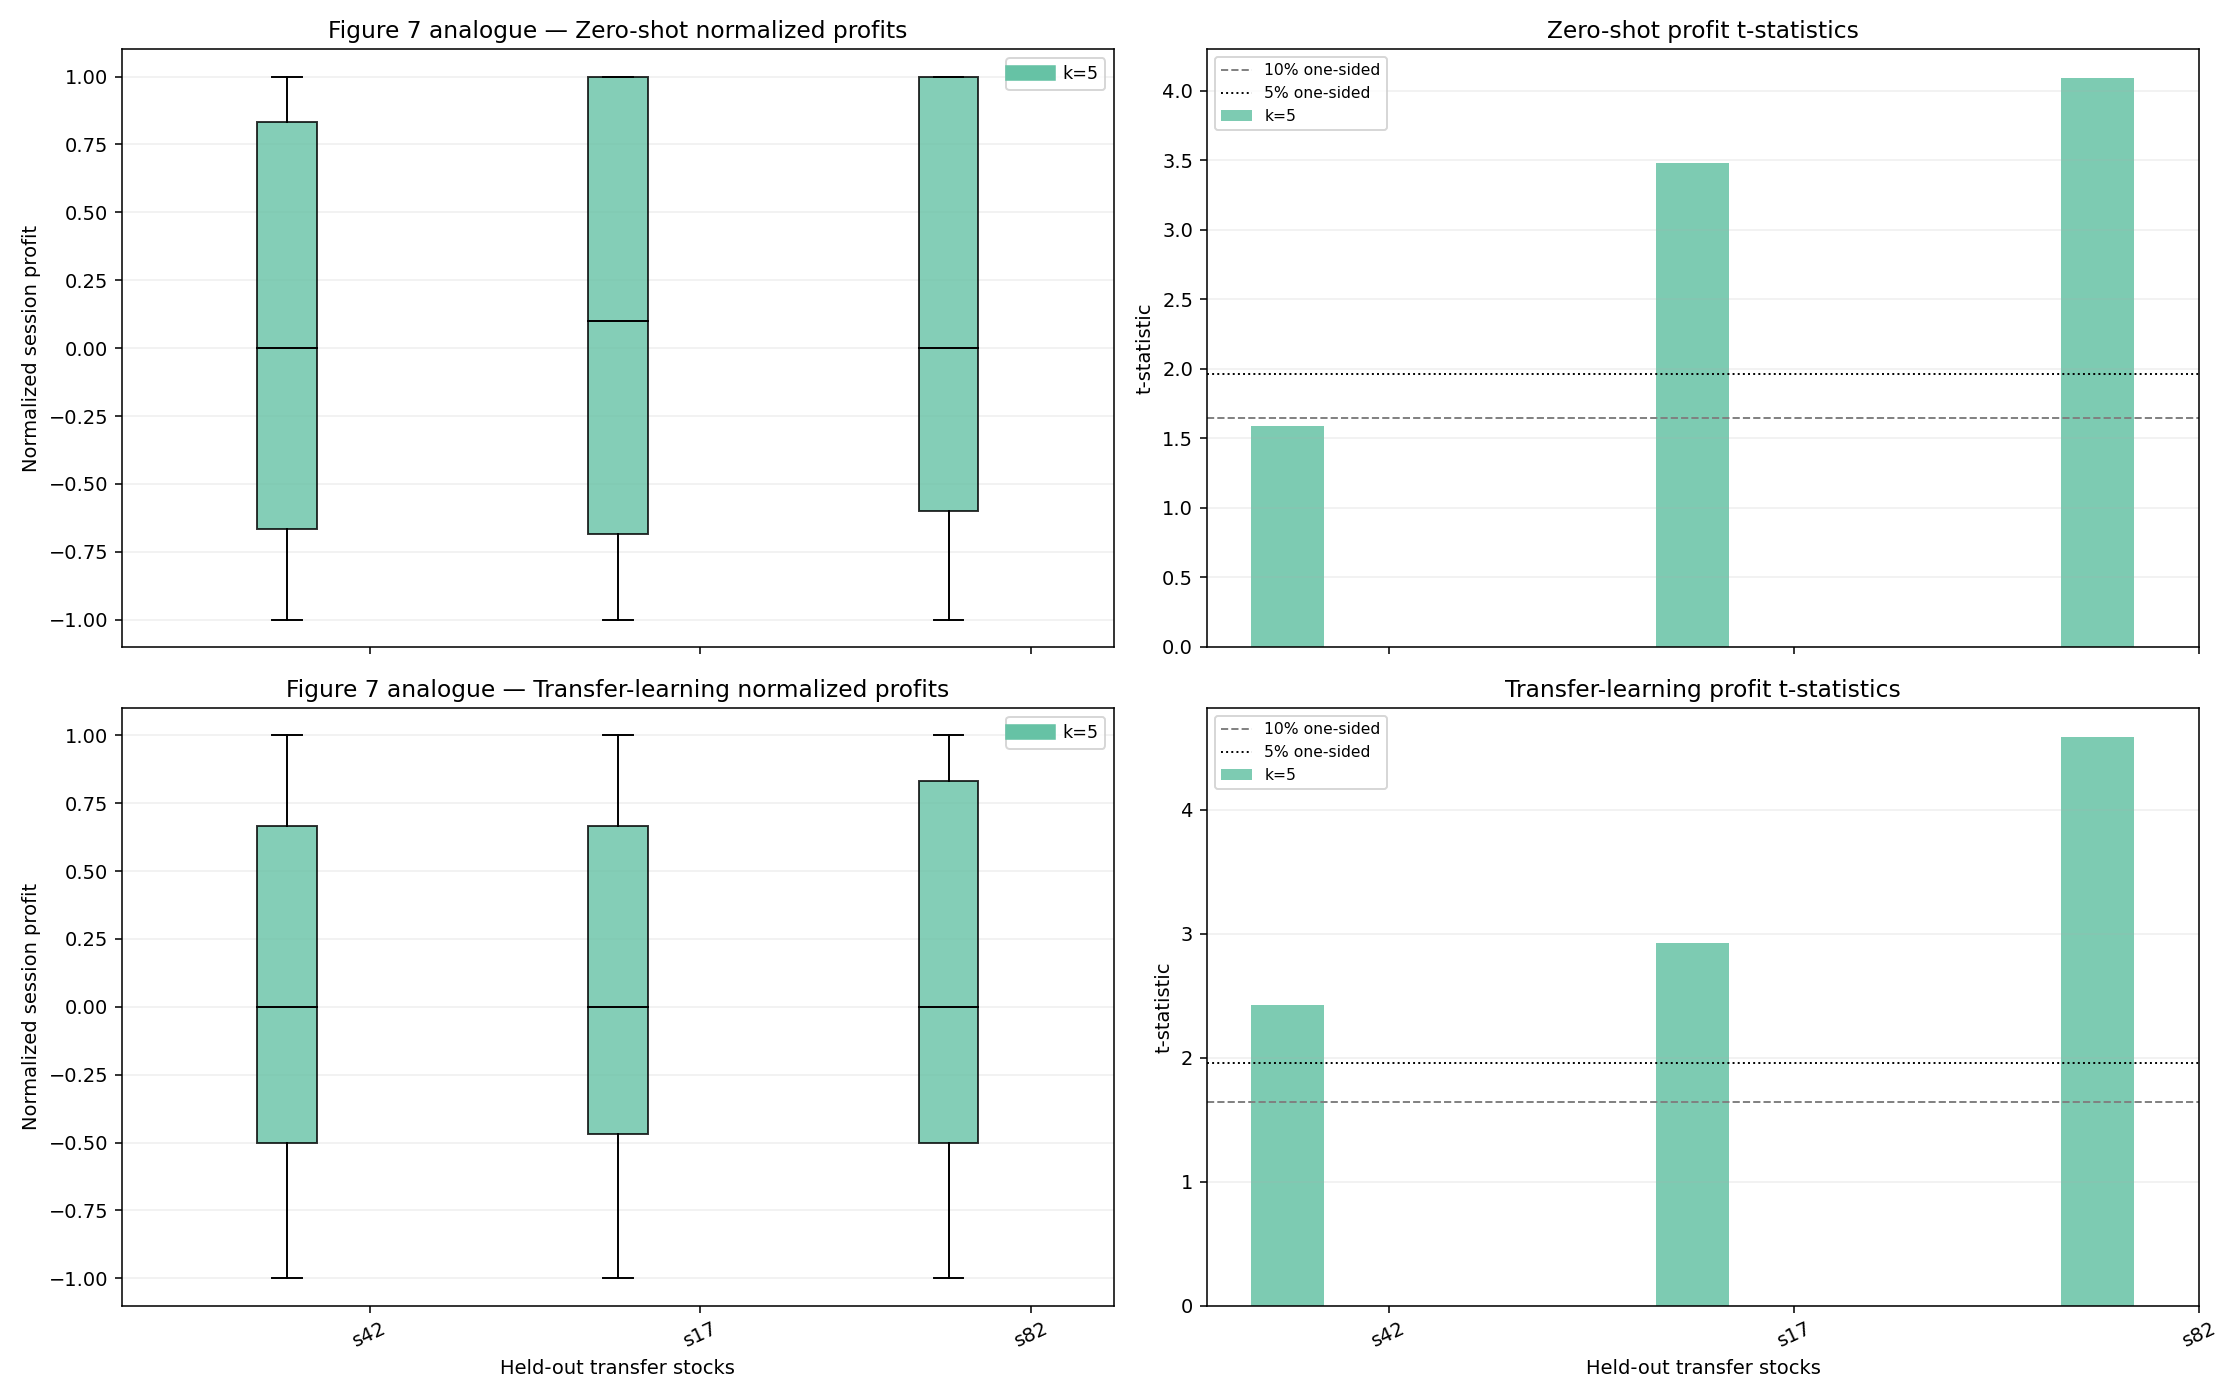

**Cumulative normalized profit curves**  \n`figure8_transfer_cum_profit.png`

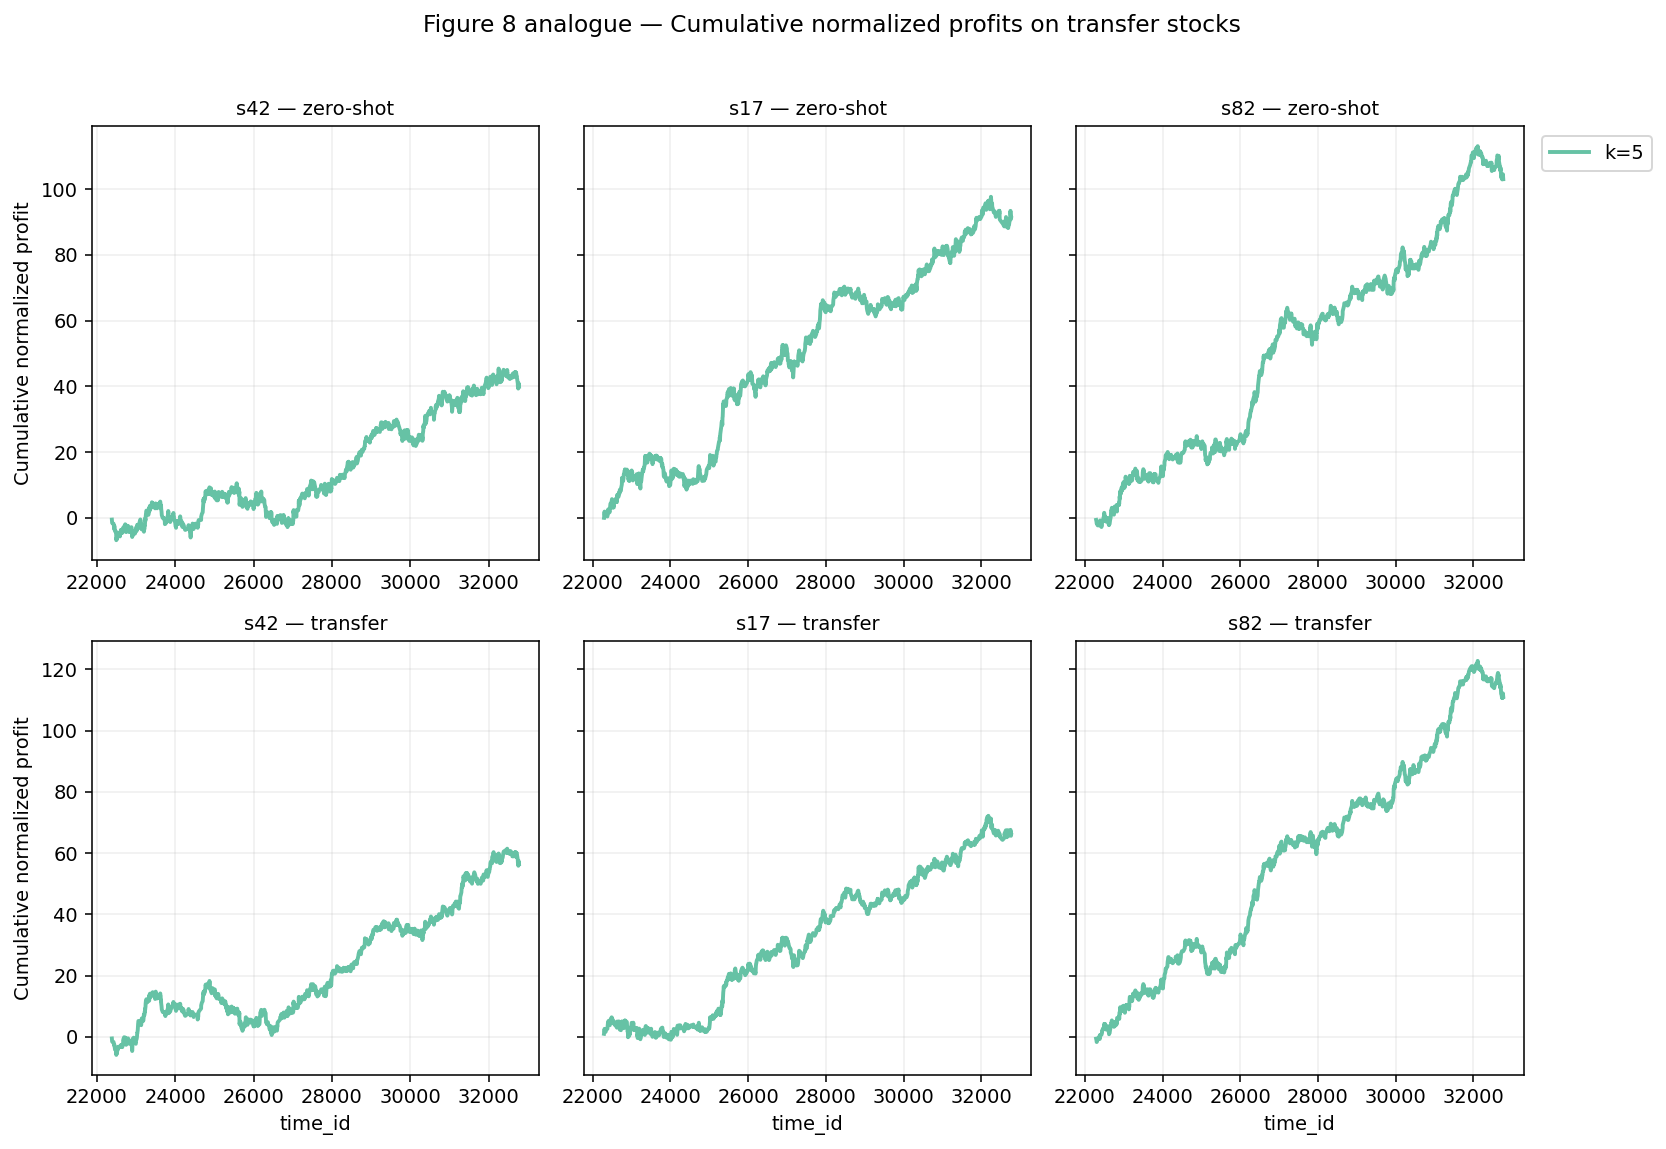

**LIME-style local explanation case**  \n`figure9_transfer_lime.png`

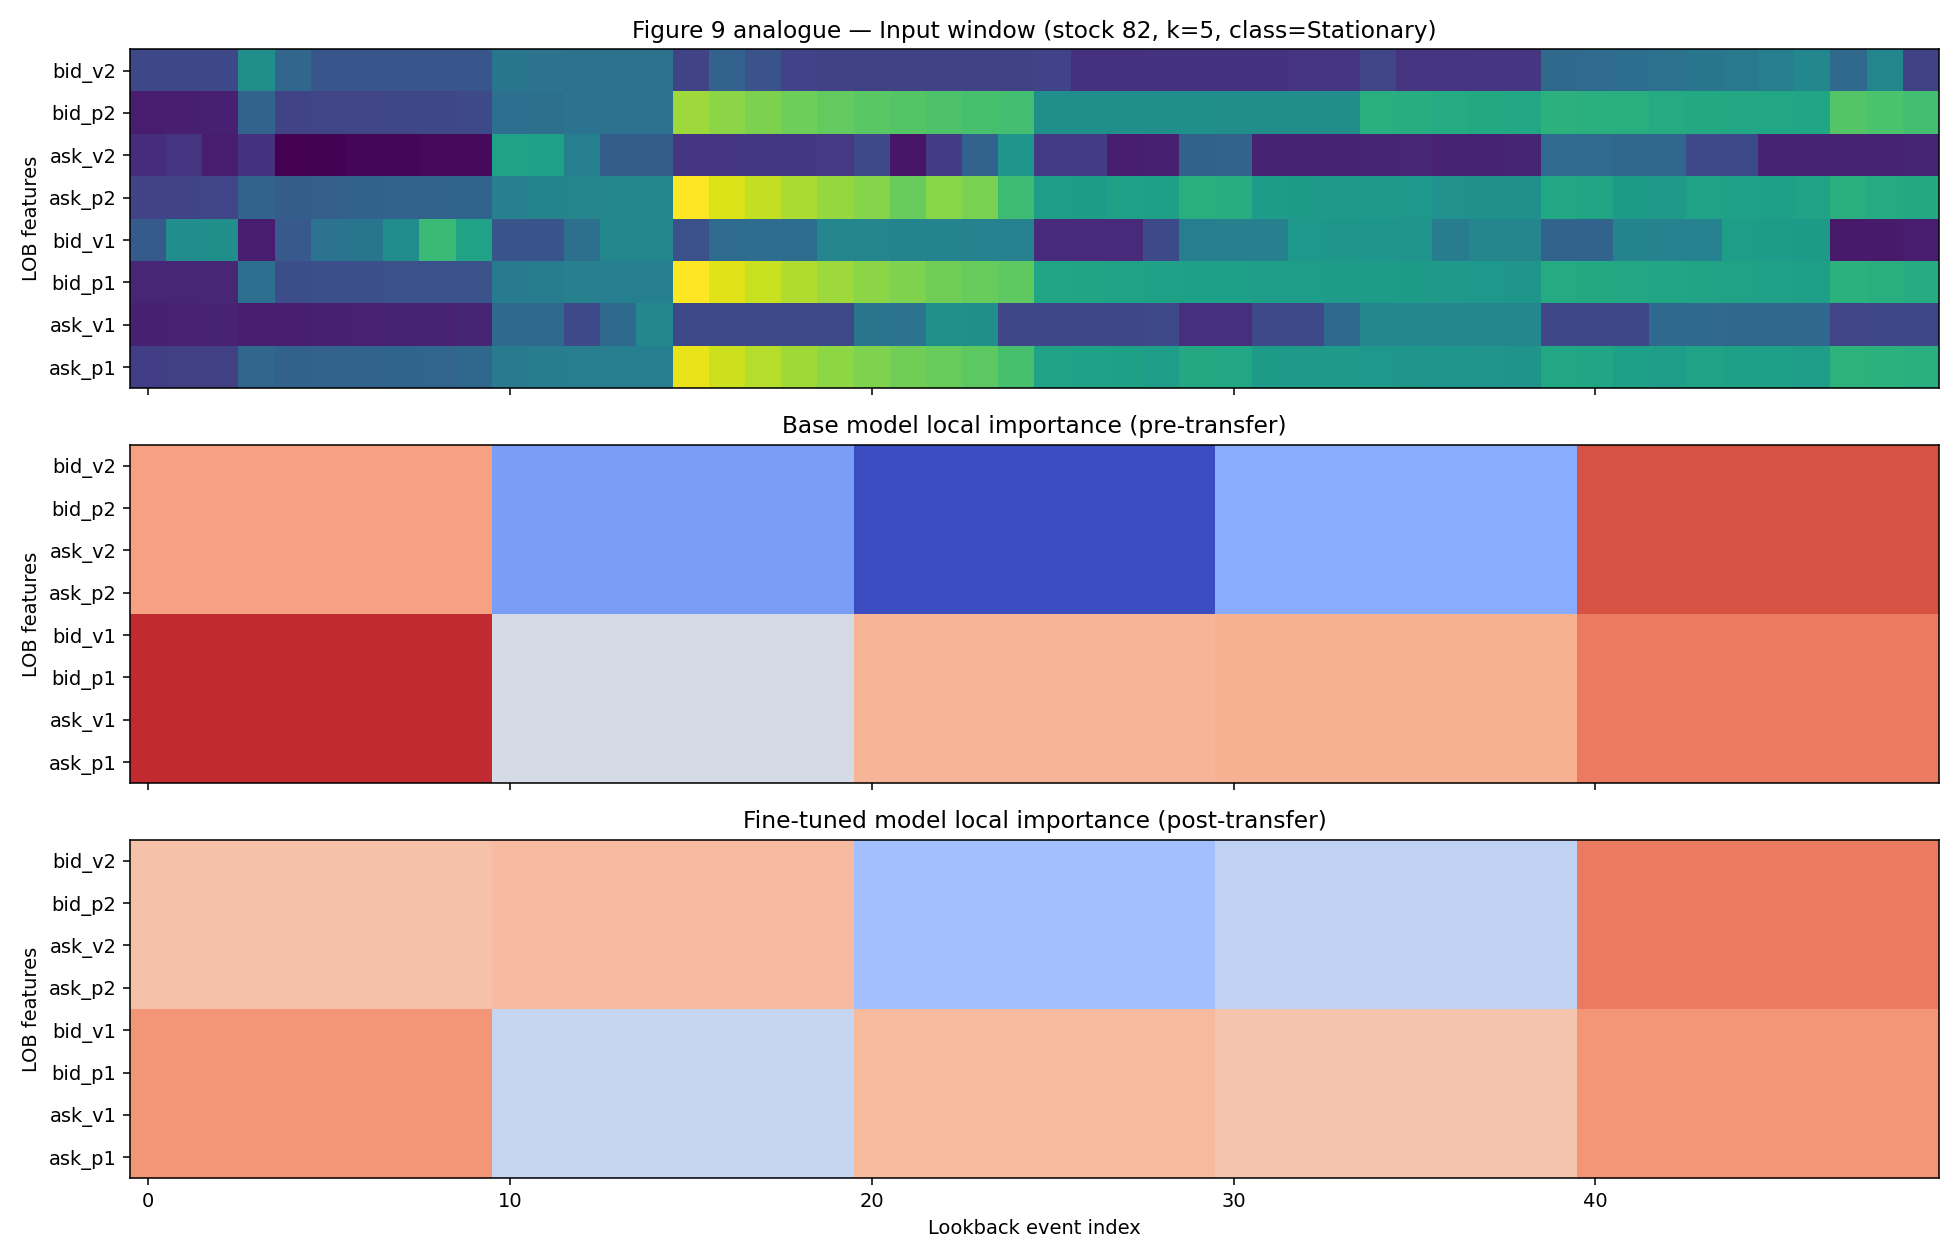

In [2]:
OPTIVER_FIGURES = [
    ('base_loss_k5.png', 'Base training loss and monitor trajectory'),
    ('cm_base_k5.png', 'Base-model confusion matrix on held-out stocks'),
    ('transfer_comparison_k5.png', 'Before/after transfer comparison on selected stocks'),
    ('transfer_regimes_k5.png', 'Transfer-mode comparison across the selected stocks'),
    ('figure6_transfer_accuracy.png', 'Per-session transfer accuracy diagnostic'),
    ('figure7_transfer_profit_tstats.png', 'Profit-style session t-statistic diagnostic'),
    ('figure8_transfer_cum_profit.png', 'Cumulative normalized profit curves'),
    ('figure9_transfer_lime.png', 'LIME-style local explanation case'),
]

for variant_name, result_dir in OPTIVER_FINAL_DIRS.items():
    display(Markdown(f'### {variant_name} figure gallery'))
    for file_name, caption in OPTIVER_FIGURES:
        path = result_dir / file_name
        if path.exists():
            display(Markdown(f'**{caption}**  \\n`{file_name}`'))
            display(Image(str(path)))

### Final Optiver Takeaway

The final Optiver report should **keep both retained variants** because they complement each other rather than one strictly dominating the other:

- **Original3** is the continuity baseline that preserves the original label semantics and demonstrates what happens when transfer learning is applied to the unmodified adaptive labels.
- **Rolling3** is the robustness branch that makes the label-distribution problem explicit and shows how different conclusions appear once the supervision signal is rebalanced with a causal rolling rule.

The key methodological point is not that one branch wins every metric. The important point is that the notebook now makes the trade-off visible: **classification quality, transfer stability, class-balance robustness, and profit-style diagnostics can disagree**. That disagreement is the real result, and it has to be shown directly in the final report rather than hidden behind a single headline accuracy number.